# Regression Task

Datasource: [Ames Housing Dataset](https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset)

# Table of Contents

1. [Data Inspection](#data-inspection)
- This section provides a comprehensive review of the dataset. We ensure the data is ready for analysis by addressing issues such as incorrect data, handling missing values through various strategies (like imputation or removal), dealing with duplicate entries, rectifying case inconsistencies, managing mixed data types through feature engineering.

2. [Univariate Analysis](#uni-variate-analysis)
- This section focuses on the independent analysis of variables. We understand their distribution through visualizations like histograms and bar charts. This helps us understand the central tendency and dispersion of individual variables.

3. [Bivariate Analysis](#bi-variate-analysis)
- This section delves into the exploration of relationships between pairs of variables. It includes the creation of scatter plots, correlation matrices, and other visualizations to comprehend the interplay between variables. This helps us understand the relationships and dependencies between different variables.

4. [Outlier Detection](#outliers)
- This section is dedicated to the identification of outliers. It explores the assumptions of various outlier removal methods, ranging from the z-score to the IQR method. This helps us ensure that our data is not skewed by extreme values.

5. [Feature Engineering](#feature-engineering)
- This section is about generating new features from existing ones to enhance the performance of machine learning models. It encompasses techniques like binning, creation of polynomial features, and interaction features. This helps us extract more information from our data and improve the predictive power of our models.

6. [Feature Selection](#feature-selection)
- This section is about choosing the most informative features for modeling. It includes techniques like mutual information and chi-square tests. This helps us reduce the dimensionality of our data and focus on the most important features.

7. [Conclusion](#conclusion)
- This section encapsulates the insights from the EDA, discusses their impact on modeling, and outlines the future steps in the project. This helps us summarize our findings and plan our next steps.

8. [Model Scoping with Pycaret](#quick-model-scoping-with-pycaret)
- This section involves a rapid scoping of various machine learning models using the Pycaret library. It includes the setup of the environment, model comparisons, and tuning of the best model. This helps us quickly identify promising models.

9. [Modelling](#modelling)
- This section involves the application of different transformations to our data with the assistance of the pipeline class. This includes scaling features, encoding categorical variables, and applying various machine learning algorithms. This helps us build and evaluate our final models.

10. [Stacking](#stacking-meta-learner)
- This involves training multiple different models (base models) and then adding a new model (meta-learner or second-level model) on top that is trained to make a final prediction based on the predictions of the base models. The base models are trained based on a complete training set, then the meta-learner model is trained to make a final prediction based on the predictions of the base models. This can lead to improved predictive performance.

12. [Voting](#voting-regressor) 
- The idea behind the Voting Regressor is to combine conceptually different machine learning regressors and return the average predicted values. Such a regressor can be useful for a set of equally well performing models in order to balance out their individual weaknesses.

13. [Blending](#blending)
- Combining different models together! 

14. [Visualisation](#visualisation)
- This section involves visualising the best pipeline, the transformations and model, along with the feature importance.

# Library Imports

In [1]:
# Third-party library imports for data loading and numerical operations
import numpy as np
import pandas as pd

# Third-party library imports for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Third-party library imports for statistical analysis
import scipy
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

# Third-party library imports for feature engineering
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

# Set configuration for sklearn
set_config(display='diagram', transform_output='pandas') 

# Loading the dataset

In [2]:
from pathlib import Path

# Resolve the project root by walking up from the working directory until data/raw is
# found, so the notebook works whether the kernel starts in the repo root (VS Code) or
# in reports/notebooks/ (JupyterLab).
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'data' / 'raw' / 'train.csv').exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError(
            "Could not locate data/raw/train.csv. Download the competition data from "
            "https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data "
            "and place train.csv / test.csv in data/raw/ at the repository root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
print(f"Project root: {PROJECT_ROOT}")

train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
train.head()

Project root: /Users/lowrenhwa/dev/zack/aiml/classical/regression/regression-ames


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print (f"Train has {train.shape[0]} rows and {train.shape[1]} columns")
print (f"Test has {test.shape[0]} rows and {test.shape[1]} columns")

Train has 1460 rows and 81 columns
Test has 1459 rows and 80 columns


Now, we have two seperate datasets, ```train``` and ```test```, common in many Kaggle competitions, which complicates things for 2 reasons.

Firstly, excluding the test data from exploratory data analysis (EDA) limits our understanding of the overall dataset distribution and potential patterns. This restriction may result in missing valuable insights that could enhance model performance.

Secondly, the preprocessing steps applied to the train dataset need to be replicated for the test dataset. This process introduces complexity and increases the likelihood of errors, especially if the preprocessing steps are not implemented consistently across both datasets.

To address these challenges, a solution involves concatenating the training and test datasets into a single dataframe. This combined dataset, referred to as ```x_all```, allows us to perform EDA on the entire dataset, enabling a comprehensive analysis that incorporates all available information.

Furthermore, by applying the same preprocessing steps to ```x_all```, we ensure consistency in data transformation across both the training and test datasets. Once preprocessing is complete, we can easily split ```x_all``` back into the original ```train``` and ```test``` datasets for subsequent model training and evaluation.

In [4]:
all_ids = pd.concat([train['Id'], test['Id']], ignore_index=True)
assert all_ids.is_unique, "'Id' column in the combined dataset has duplicate values, cannot be used as index."

# Subtract 1 from the 'Id' column (since index starts from 0) and set it as the index for train and test
train = train.set_index(train['Id'] - 1)
test = test.set_index(test['Id'] - 1)

# Drop the 'Id' column as it's now the index
train = train.drop('Id', axis=1)
test = test.drop('Id', axis=1)

# Keep an untouched copy of the raw training frame. Outlier thresholds are defined on
# the ORIGINAL columns, but the outlier rows must only be removed from the training
# split (see the Outliers section) -- never from validation or test.
raw_train = train.copy()

# Concatenate train and test
x_all = pd.concat([train.drop("SalePrice", axis=1), test], axis=0)

# Get the target variable from train
y_train = train[['SalePrice']]

# Data Inspection

In [5]:
x_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 0 to 2918
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   int64  
 1   MSZoning       2915 non-null   object 
 2   LotFrontage    2433 non-null   float64
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   object 
 5   Alley          198 non-null    object 
 6   LotShape       2919 non-null   object 
 7   LandContour    2919 non-null   object 
 8   Utilities      2917 non-null   object 
 9   LotConfig      2919 non-null   object 
 10  LandSlope      2919 non-null   object 
 11  Neighborhood   2919 non-null   object 
 12  Condition1     2919 non-null   object 
 13  Condition2     2919 non-null   object 
 14  BldgType       2919 non-null   object 
 15  HouseStyle     2919 non-null   object 
 16  OverallQual    2919 non-null   int64  
 17  OverallCond    2919 non-null   int64  
 18  YearBuilt    

### Checking for duplicate rows

In [6]:
duplicate_rows = x_all.duplicated()
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

Number of duplicate rows: 2


### Checking for missing values

In [7]:
# Calculate missing data
missing_data = x_all.isnull().sum()
missing_data = missing_data[missing_data > 0]  # Only consider columns with missing data
missing_percentage = (missing_data / len(x_all)) * 100

# Combine the count and percentage into a DataFrame for nicer formatting
missing_df = pd.DataFrame({'Count': missing_data, 'Percentage': missing_percentage})

# Sort by percentage of missing values
missing_df = missing_df.sort_values(by='Percentage', ascending=False)

print("Columns with missing data, their count and percentage:")
missing_df

Columns with missing data, their count and percentage:


,Count,Percentage
PoolQC,2909,99.657417
MiscFeature,2814,96.402878
Alley,2721,93.216855
Fence,2348,80.438506
MasVnrType,1766,60.500171
FireplaceQu,1420,48.646797
LotFrontage,486,16.649538
GarageFinish,159,5.447071
GarageQual,159,5.447071
GarageCond,159,5.447071


A significant number of columns in this dataset contain missing data. It's particularly notable that six columns have more than 15% of their values missing. The reasons for missing data can vary widely, from human error to other factors. However, in this dataset, it's important to note that for some features, the "NA" value is meaningful. For instance, in the 'PoolQC' feature, which represents pool quality, "NA" indicates the absence of a pool.

```PoolQC```: Pool quality
- Ex - Excellent
- Gd - Good
- TA - Average/Typical
- Fa - Fair
- NA - No Pool

In the subsequent steps, we will address these missing values by imputing them with appropriate values.

### Checking for constant values (no-variance features)

In [8]:
constant_columns = [col for col in x_all.columns if x_all[col].nunique() <= 1]
print(f"Columns with constant values: {constant_columns}")

Columns with constant values: []


### Checking for mixed types

In [9]:
# # Iterate over the columns
# for column in x_all.columns:
#     # Get the unique types of the column values
#     unique_types = set(x_all[column].apply(type))
    
#     # If more than one unique type is found, print the column name and the unique values of each type
#     if len(unique_types) > 1:
#         print(f"{column} contains mixed types: {unique_types}")
#         for value_type in unique_types:
#             print(f"Unique {value_type} values: {x_all[column].apply(lambda x: x if type(x) == value_type and not pd.isnull(x) else None).dropna().unique()}")

### Checking for inconsistent values

In [10]:
# Check for negative values in numerical columns
numerical_cols = x_all.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if x_all[col].lt(0).any():
        print(f"Column {col} contains negative values")

### Checking for formatting errors (case inconsistency)

In [11]:
categorical_cols = x_all.select_dtypes(include=['object']).columns
# Check for case inconsistency in categorical columns
for col in categorical_cols:
    # Convert all values to lower case and check if the number of unique values decreases
    num_unique_values_original = x_all[col].nunique()
    num_unique_values_lower = x_all[col].str.lower().nunique()
    if num_unique_values_lower < num_unique_values_original:
        print(f"Column {col} has case inconsistency")

### Transforming Features to Their Appropriate Types

In general, we can classify features in our dataset into three main types:

* **Continuous**: These are numeric variables that can take an infinite number of values between any two values. They are often visualized using histograms and scatter plots, and can be transformed via methods such as scaling and normalization.

* **Ordinal**: These are variables that have two or more categories, but the categories have an inherent order. For example, a feature like 'education level', with values like 'high school', 'bachelor's degree', 'master's degree', would be an ordinal feature. These are often visualized using bar charts or line plots, and can be processed using methods such as label encoding.

* **Categorical/Nominal**: These are variables that have two or more categories but without any kind of order or priority. For example, a feature like 'color', with values like 'red', 'blue', 'green', would be a categorical feature. These are often visualized using bar charts or pie charts, and can be processed using methods such as one-hot encoding.

Separating the types of features is beneficial for our Exploratory Data Analysis (EDA), as we utilize different visualization methods for each type, depending on the nature of the problem and the target variable.

Moreover, different types of preprocessing methods are applied to each feature type. For instance, continuous features might be scaled to a standard range, ordinal features might be label encoded, and categorical features might be one-hot encoded. This ensures that our machine learning algorithms can interpret the features correctly.

In [12]:
x_all = x_all.replace({"MSSubClass" : {20 : "SC20", 30 : "SC30", 40 : "SC40", 45 : "SC45", 
                                       50 : "SC50", 60 : "SC60", 70 : "SC70", 75 : "SC75", 
                                       80 : "SC80", 85 : "SC85", 90 : "SC90", 120 : "SC120", 
                                       150 : "SC150", 160 : "SC160", 180 : "SC180", 190 : "SC190"},
                        "MoSold" : {1 : "Jan", 2 : "Feb", 3 : "Mar", 4 : "Apr", 5 : "May", 6 : "Jun",
                                    7 : "Jul", 8 : "Aug", 9 : "Sep", 10 : "Oct", 11 : "Nov", 12 : "Dec"}
                        })

The ```MSSubClass``` and ```MoSold``` features, originally numerical, are being converted to categorical. ```MSSubClass``` represents the building class with different numerical codes, which are now prefixed with 'SC' to indicate them as separate categories. ```MoSold```, initially represented as numbers from 1 to 12, is transformed to corresponding month abbreviations, turning it into a nominal feature.

In [13]:
# Encode some categorical features as ordinal ordered numbers when there is information in the order
x_all = x_all.replace({"Alley" : {np.nan: 0, "Grvl" : 1, "Pave" : 2},
                       "BsmtCond" : {np.nan : 0, "Po" : 1, "Fa" : 2, "TA" : 3, "Gd" : 4, "Ex" : 5},  # BsmtQual: Evaluates the height of the basement
                       "BsmtExposure" : {np.nan : 0, "No": 1, "Mn" : 2, "Av": 3, "Gd" : 4}, #BsmtExposure: Refers to walkout or garden level walls
                       "BsmtFinType1" : {np.nan : 0, "Unf" : 1, "LwQ": 2, "Rec" : 3, "BLQ" : 4, "ALQ" : 5, "GLQ" : 6}, #BsmtFinType1: Rating of basement finished area
                       "BsmtFinType2" : {np.nan: 0, "Unf" : 1, "LwQ": 2, "Rec" : 3, "BLQ" : 4, "ALQ" : 5, "GLQ" : 6}, #BsmtFinType2: Rating of basement finished area (if multiple types)
                       "BsmtQual" : {np.nan : 0, "Po" : 1, "Fa" : 2, "TA": 3, "Gd" : 4, "Ex" : 5}, #BsmtQual: Evaluates the height of the basement
                       "ExterCond" : {"Po" : 1, "Fa" : 2, "TA": 3, "Gd": 4, "Ex" : 5}, #ExterCond: Evaluates the present condition of the material on the exterior
                       "ExterQual" : {"Po" : 1, "Fa" : 2, "TA": 3, "Gd": 4, "Ex" : 5}, #ExterQual: Evaluates the quality of the material on the exterior
                       "FireplaceQu" : {np.nan : 0, "Po" : 1, "Fa" : 2, "TA" : 3, "Gd" : 4, "Ex" : 5}, #FireplaceQu: Fireplace quality
                       "Functional" : {"Sal" : 1, "Sev" : 2, "Maj2" : 3, "Maj1" : 4, "Mod": 5, "Min2" : 6, "Min1" : 7, "Typ" : 8}, # Home functionality (Assume typical unless deductions are warranted)
                       "GarageCond" : {np.nan : 0, "Po" : 1, "Fa" : 2, "TA" : 3, "Gd" : 4, "Ex" : 5}, #GarageCond: Evaluates the present condition of the garage
                       "GarageQual" : {np.nan : 0, "Po" : 1, "Fa" : 2, "TA" : 3, "Gd" : 4, "Ex" : 5}, #GarageQual: Garage quality
                       "HeatingQC" : {"Po" : 1, "Fa" : 2, "TA" : 3, "Gd" : 4, "Ex" : 5}, #HeatingQC: Heating quality and condition
                       "KitchenQual" : {"Po" : 1, "Fa" : 2, "TA" : 3, "Gd" : 4, "Ex" : 5}, #KitchenQual: Kitchen quality
                       "LandSlope" : {"Sev" : 1, "Mod" : 2, "Gtl" : 3}, #LandSlope: Slope of property
                       "LotShape" : {"IR3" : 1, "IR2" : 2, "IR1" : 3, "Reg" : 4},  #LotShape: General shape of property
                       "PavedDrive" : {"N" : 0, "P" : 1, "Y" : 2}, #PavedDrive: Paved driveway
                       "PoolQC" : {np.nan : 0, "Fa" : 1, "TA" : 2, "Gd" : 3, "Ex" : 4}, #PoolQC: Pool quality
                       "Street" : {"Grvl" : 1, "Pave" : 2}, #Street: Type of road access
                       "Utilities" : {"ELO" : 1, "NoSeWa" : 2, "NoSewr" : 3, "AllPub" : 4}, #Utilities: Type of utilities available
                       "Fence": {np.nan : 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4}} #Fence: Fence quality (worst -> best, consistent with the mappings above)
                     )

# EDA
With our dataset now cleaned and preprocessed, we can proceed to the EDA phase. Before diving into the analysis, we'll first categorize our features into three groups: continuous, ordinal, and categorical. This classification allows us to employ different visualization methods tailored to the nature of each feature type.

In [14]:
numerical_cols = x_all.select_dtypes(include=[np.number]).columns
categorical_cols = x_all.select_dtypes(include=['object']).columns

ordinal_features = ['Alley', 
                    'BsmtCond', 
                    'BsmtExposure', 
                    'BsmtFinType1', 
                    'BsmtFinType2', 
                    'BsmtQual', 
                    "ExterCond", 
                    "ExterQual", 
                    "FireplaceQu", 
                    "Functional", 
                    "GarageCond", 
                    "GarageQual", 
                    "HeatingQC", 
                    "KitchenQual", 
                    "LandSlope", 
                    "LotShape", 
                    "PavedDrive", 
                    "PoolQC", 
                    "Street", 
                    "Utilities",
                    'OverallQual',
                    'OverallCond',
                    'BsmtFullBath',
                    'BsmtHalfBath',
                    'FullBath',
                    'HalfBath',
                    'BedroomAbvGr', 
                    'KitchenAbvGr', 
                    'TotRmsAbvGrd', 
                    'Fireplaces', 
                    'GarageCars',
                    'Fence']

# Check if any of the ordinal columns are not in the numerical or categorical columns
continuous_features = [col for col in numerical_cols if col not in ordinal_features]
categorical_features = [col for col in categorical_cols if col not in ordinal_features]

Histograms and box plots are excellent tools for visualizing continuous variables.

Histograms provide a visual interpretation of numerical data by indicating the number of data points that lie within a range of values, known as a bin. They effectively represent the underlying frequency distribution (shape) of a set of continuous data. This allows the inspection of the data for its underlying distribution (e.g., normal distribution), outliers, skewness, etc.

Box plots, on the other hand, provide a summary of the statistical data through their quartiles. They also identify outliers within the data. The line in the middle of the box is the median of the data, and the box represents the interquartile range (from the first quartile to the third quartile), giving a quick graphical representation of the center and spread of the data.

For ordinal and categorical variables, bar plots are used.

Bar plots are useful for displaying and comparing the quantity, frequency, or other measure (e.g., mean) for different categories or groups. The x-axis represents the categories and the y-axis represents the quantity. This makes it easy to compare quantities for different categories in the data and can highlight significant differences between categories.

In [15]:
def uni_hist_plot(data, continuous_features, plot_num_cols=3):
    num_plots = len(continuous_features)
    total_cols = plot_num_cols
    total_rows = num_plots // total_cols + 1

    fig = make_subplots(rows=total_rows, cols=total_cols)

    for i, var in enumerate(continuous_features):
        row = i // total_cols + 1
        pos = i % total_cols + 1
        fig.add_trace(go.Histogram(x=data[var], nbinsx=50, name=var), row=row, col=pos)

    fig.update_layout(height=300*total_rows, width=400*total_cols, title_text="Distribution of continuous features")
    fig.show()

def uni_box_plot(data, continuous_features, plot_num_cols=3):
    num_plots = len(continuous_features)
    total_cols = plot_num_cols
    total_rows = num_plots // total_cols + 1

    fig = make_subplots(rows=total_rows, cols=total_cols)

    for i, var in enumerate(continuous_features):
        row = i // total_cols + 1
        pos = i % total_cols + 1
        fig.add_trace(go.Box(y=data[var], name=var), row=row, col=pos)

    fig.update_layout(height=300*total_rows, width=400*total_cols, title_text="Boxplot of continuous features")
    fig.show()

def uni_count_plot(data, categorical_features, plot_num_cols=3):
    num_plots = len(categorical_features)
    total_cols = plot_num_cols
    total_rows = num_plots // total_cols + 1

    fig = make_subplots(rows=total_rows, cols=total_cols)

    for i, var in enumerate(categorical_features):
        row = i // total_cols + 1
        pos = i % total_cols + 1
        fig.add_trace(go.Bar(x=data[var].value_counts().index, y=data[var].value_counts().values, name=var), row=row, col=pos)

    fig.update_layout(height=300*total_rows, width=400*total_cols, title_text="Count of categorical features")
    fig.show()

## Uni-variate Analysis

### Target Variable - SalePrice

In [16]:
y_train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [17]:
sns.displot(y_train['SalePrice'], kde=True, height=3, aspect=3)
plt.title('{} Distribution'.format('SalePrice'), fontsize=20)
plt.show()

# skewness and kurtosis
print("Skewness: " + str(y_train['SalePrice'].skew()))
print("Kurtosis: " + str(y_train['SalePrice'].kurt()))

<Figure size 900x300 with 1 Axes>

Skewness: 1.8828757597682129
Kurtosis: 6.536281860064529


Skewness measures the asymmetry of a probability distribution about its mean. Positive skewness indicates a distribution with an asymmetric tail extending towards more positive values. The skewness of 1.88 for ```SalePrice``` suggests that the distribution is moderately positively skewed. This means that most of the houses are sold at a price below the average, with a few houses sold at much higher prices.

Kurtosis measures the "tailedness" of the probability distribution. A kurtosis of 6.54 indicates that the ```SalePrice``` distribution has heavier tails and a sharper peak than the normal distribution. In other words, it has more outliers (values that are significantly higher or lower than the mean) and the values are more concentrated around the mean.

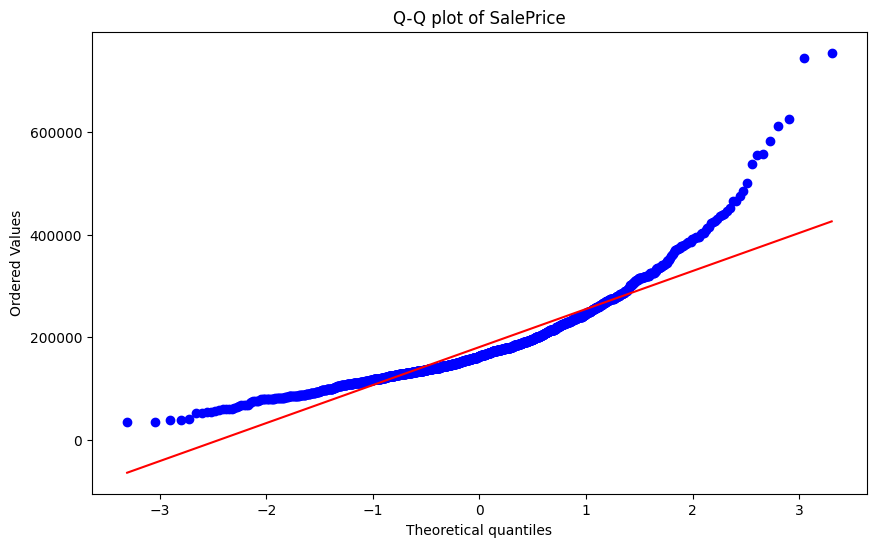

Statistics=0.870, p=0.000
The 'SalePrice' variable does not appear to follow a Gaussian distribution (reject H0)


In [18]:
# Q-Q plot
plt.figure(figsize=(10, 6))
scipy.stats.probplot(y_train['SalePrice'], dist="norm", plot=plt)
plt.title('Q-Q plot of SalePrice')
plt.show()

# Shapiro-Wilk test
stat, p = scipy.stats.shapiro(y_train['SalePrice'])
print('Statistics=%.3f, p=%.3f' % (stat, p))

# Check if the data follows a Gaussian distribution
alpha = 0.05
if p > alpha:
    print("The 'SalePrice' variable appears to follow a Gaussian distribution (fail to reject H0)")
else:
    print("The 'SalePrice' variable does not appear to follow a Gaussian distribution (reject H0)")

The Shapiro-Wilk test is a way to tell if a random sample comes from a normal distribution. The null hypothesis of this test is that the data are normally distributed. The p-value returned by this test is 0.000, which is less than the typical threshold value of 0.05. This means that we reject the null hypothesis and conclude that the ```SalePrice``` variable does not follow a normal distribution.

In many statistical modeling techniques, including regression, the normality of the dependent variable can be an important assumption. If this assumption is violated, the model's predictions may be unreliable or inefficient. Thus, we might need a transformation such as log transformation.

### Continuous Features

In [19]:
for i in range(0, len(continuous_features), 5):
    print(', '.join(continuous_features[i:i+5]))

x_all[continuous_features].describe().T

LotFrontage, LotArea, YearBuilt, YearRemodAdd, MasVnrArea
BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, 1stFlrSF
2ndFlrSF, LowQualFinSF, GrLivArea, GarageYrBlt, GarageArea
WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch
PoolArea, MiscVal, YrSold


,count,mean,std,min,25%,50%,75%,max
LotFrontage,2433.0,69.305795,23.344905,21.0,59.0,68.0,80.0,313.0
LotArea,2919.0,10168.114080,7886.996359,1300.0,7478.0,9453.0,11570.0,215245.0
YearBuilt,2919.0,1971.312778,30.291442,1872.0,1953.5,1973.0,2001.0,2010.0
YearRemodAdd,2919.0,1984.264474,20.894344,1950.0,1965.0,1993.0,2004.0,2010.0
MasVnrArea,2896.0,102.201312,179.334253,0.0,0.0,0.0,164.0,1600.0
BsmtFinSF1,2918.0,441.423235,455.610826,0.0,0.0,368.5,733.0,5644.0
BsmtFinSF2,2918.0,49.582248,169.205611,0.0,0.0,0.0,0.0,1526.0
BsmtUnfSF,2918.0,560.772104,439.543659,0.0,220.0,467.0,805.5,2336.0
TotalBsmtSF,2918.0,1051.777587,440.766258,0.0,793.0,989.5,1302.0,6110.0
1stFlrSF,2919.0,1159.581706,392.362079,334.0,876.0,1082.0,1387.5,5095.0


In [20]:
uni_hist_plot(x_all, continuous_features, plot_num_cols=3)

In [21]:
uni_box_plot(x_all, continuous_features, plot_num_cols=3)

### Ordinal Features

In [22]:
for i in range(0, len(ordinal_features), 5):
    print(', '.join(ordinal_features[i:i+5]))

x_all[ordinal_features].describe().T

Alley, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2
BsmtQual, ExterCond, ExterQual, FireplaceQu, Functional
GarageCond, GarageQual, HeatingQC, KitchenQual, LandSlope
LotShape, PavedDrive, PoolQC, Street, Utilities
OverallQual, OverallCond, BsmtFullBath, BsmtHalfBath, FullBath
HalfBath, BedroomAbvGr, KitchenAbvGr, TotRmsAbvGrd, Fireplaces
GarageCars, Fence


,count,mean,std,min,25%,50%,75%,max
Alley,2919.0,0.094553,0.372966,0.0,0.0,0.0,0.0,2.0
BsmtCond,2919.0,2.918465,0.574950,0.0,3.0,3.0,3.0,4.0
BsmtExposure,2919.0,1.623844,1.070026,0.0,1.0,1.0,2.0,4.0
BsmtFinType1,2919.0,3.541624,2.113851,0.0,1.0,4.0,6.0,6.0
BsmtFinType2,2919.0,1.273724,0.955180,0.0,1.0,1.0,1.0,6.0
BsmtQual,2919.0,3.477561,0.905448,0.0,3.0,4.0,4.0,5.0
ExterCond,2919.0,3.085646,0.372361,1.0,3.0,3.0,3.0,5.0
ExterQual,2919.0,3.396711,0.580293,2.0,3.0,3.0,4.0,5.0
FireplaceQu,2919.0,1.768071,1.806619,0.0,0.0,1.0,4.0,5.0
Functional,2917.0,7.848132,0.639820,2.0,8.0,8.0,8.0,8.0


In [23]:
uni_count_plot(x_all, ordinal_features, plot_num_cols=3)

### Categorical Features

In [24]:
for i in range(0, len(categorical_features), 5):
    print(', '.join(categorical_features[i:i+5]))

x_all[categorical_features].describe().T

MSSubClass, MSZoning, LandContour, LotConfig, Neighborhood
Condition1, Condition2, BldgType, HouseStyle, RoofStyle
RoofMatl, Exterior1st, Exterior2nd, MasVnrType, Foundation
Heating, CentralAir, Electrical, GarageType, GarageFinish
MiscFeature, MoSold, SaleType, SaleCondition


,count,unique,top,freq
MSSubClass,2919,16,SC20,1079
MSZoning,2915,5,RL,2265
LandContour,2919,4,Lvl,2622
LotConfig,2919,5,Inside,2133
Neighborhood,2919,25,NAmes,443
Condition1,2919,9,Norm,2511
Condition2,2919,8,Norm,2889
BldgType,2919,5,1Fam,2425
HouseStyle,2919,8,1Story,1471
RoofStyle,2919,6,Gable,2310


In [25]:
uni_count_plot(x_all, categorical_features, plot_num_cols=3)

## Bi-variate Analysis

### Multi-collinearity

Multi-collinearity is a statistical phenomenon where two or more predictor variables in a multiple regression model are highly correlated. In other words, one predictor variable can be linearly predicted from the others with a substantial degree of accuracy.

Multi-collinearity can pose problems in the regression context for several reasons:

- It can cause the model's estimated coefficients to be unreliable or unstable. Small changes in the data can lead to large changes in the model estimates, making interpretation difficult.

- It can inflate the variance of the regression coefficients, making them statistically insignificant when they should be significant. This can lead to overfitting where the model fits the training data well but performs poorly on unseen data.

- It can make it difficult to determine the effect of individual predictors on the response variable (i.e., it becomes hard to tell which variable is contributing to the prediction).

We can use a heatmap of the correlation matrix to determine which variables are highly correlated.

<Axes: >

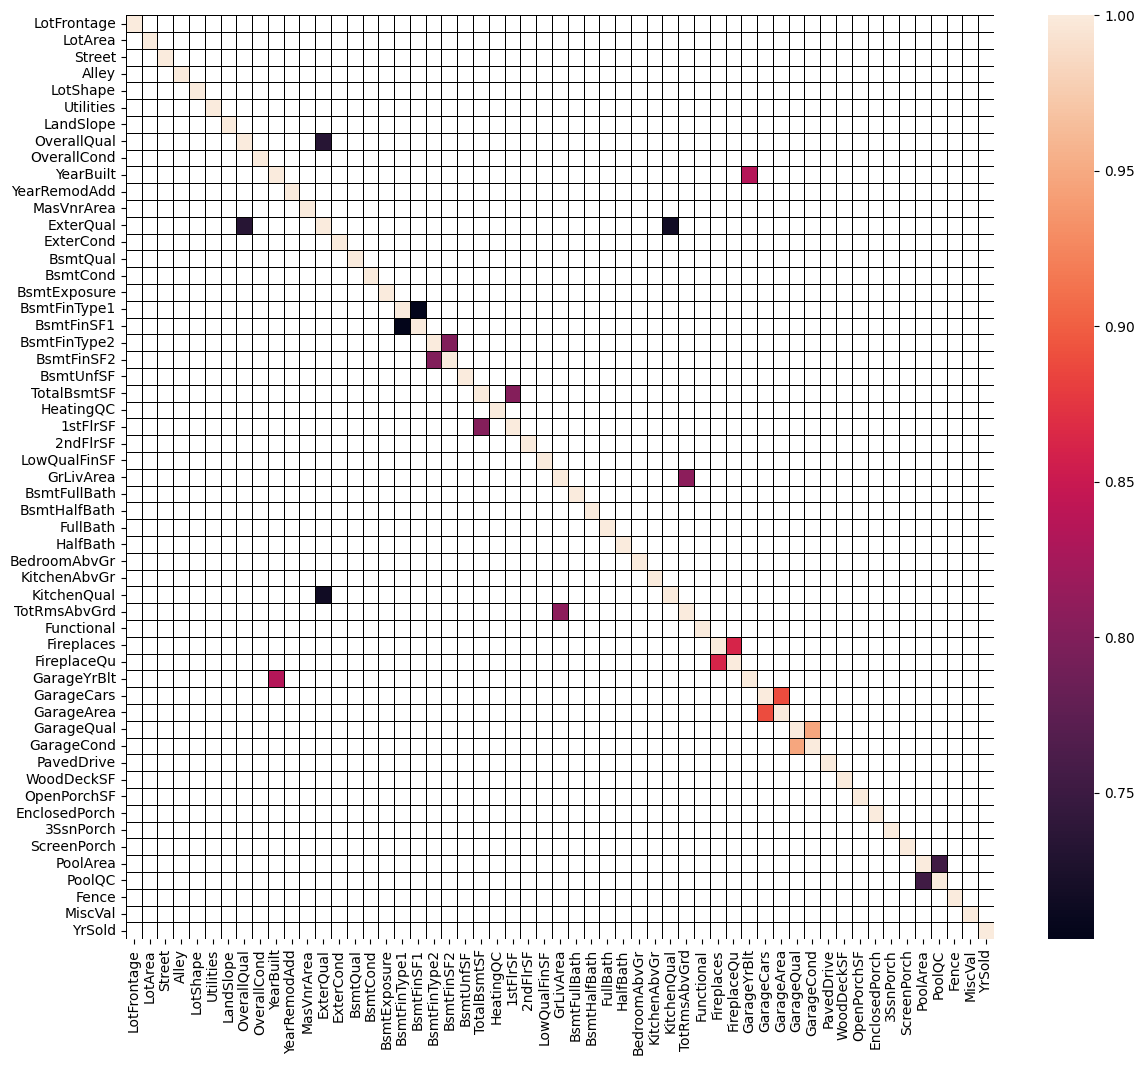

In [26]:
plt.figure(figsize=(14,12))
correlation = x_all.corr(numeric_only=True)
# Use the ABSOLUTE correlation for the mask: `correlation <= 0.7` silently hides
# strong NEGATIVE relationships (e.g. -0.9), which are just as collinear.
sns.heatmap(correlation, mask = correlation.abs() <= 0.7, linewidth=0.5, linecolor='Black')

 **Highly Correlated variables**:
* ```PoolQC``` and ```PoolArea```
* ```GarageArea``` and ```GarageCars```
* ```GarageCond``` and ```GarageQual```
* ```GarageYrBlt``` and ```YearBuilt```
* ```Fireplaces``` and ```FireplaceQu```
* ```TotRmsAbvGrd``` and ```GrLivArea```
* ```1stFlrSF``` and ```TotalBsmtSF```
* ```BsmtFinSF1``` and ```BsmtFinType1```
* ```BsmtFinSF2``` and ```BsmtFinType2```
* ```OverallQual``` and ```ExterQual```
* ```KitchenQual``` and ```ExterQual```

The high collinearity of these variables are not suprising. For example, ```GarageArea``` and ```GarageCars``` are highly correlated because they both measure the size of the garage. ```GarageArea``` measures the size in square feet, while ```GarageCars``` measures the size in terms of the number of cars that can fit. They are essentially capturing the same information, so it's not surprising that they are highly correlated.

Similarly, ```TotRmsAbvGrd``` and ```GrLivArea``` are highly correlated. ```TotRmsAbvGrd``` is the total rooms above grade (does not include bathrooms), and ```GrLivArea``` is the above grade (ground) living area in square feet. A larger living area is likely to have more rooms, so these two variables are expected to be correlated.

### Bivariate Analysis of Target and Numerical Features

In [27]:
# Retrieve the train and test data from x_all
x_train = x_all.loc[train.index]
x_test = x_all.loc[test.index]

# Combine x_train with y_train
assert x_train.shape[0] == y_train.shape[0], "Number of rows in x_train and y_train do not match"
combined = pd.concat([x_train, y_train], axis=1)

# print out correlation scores of all numeric features with the target variable
corr = combined.corr(numeric_only=True)
corr[['SalePrice']].sort_values(['SalePrice'], ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
ExterQual,0.682639
KitchenQual,0.659600
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
BsmtQual,0.585207


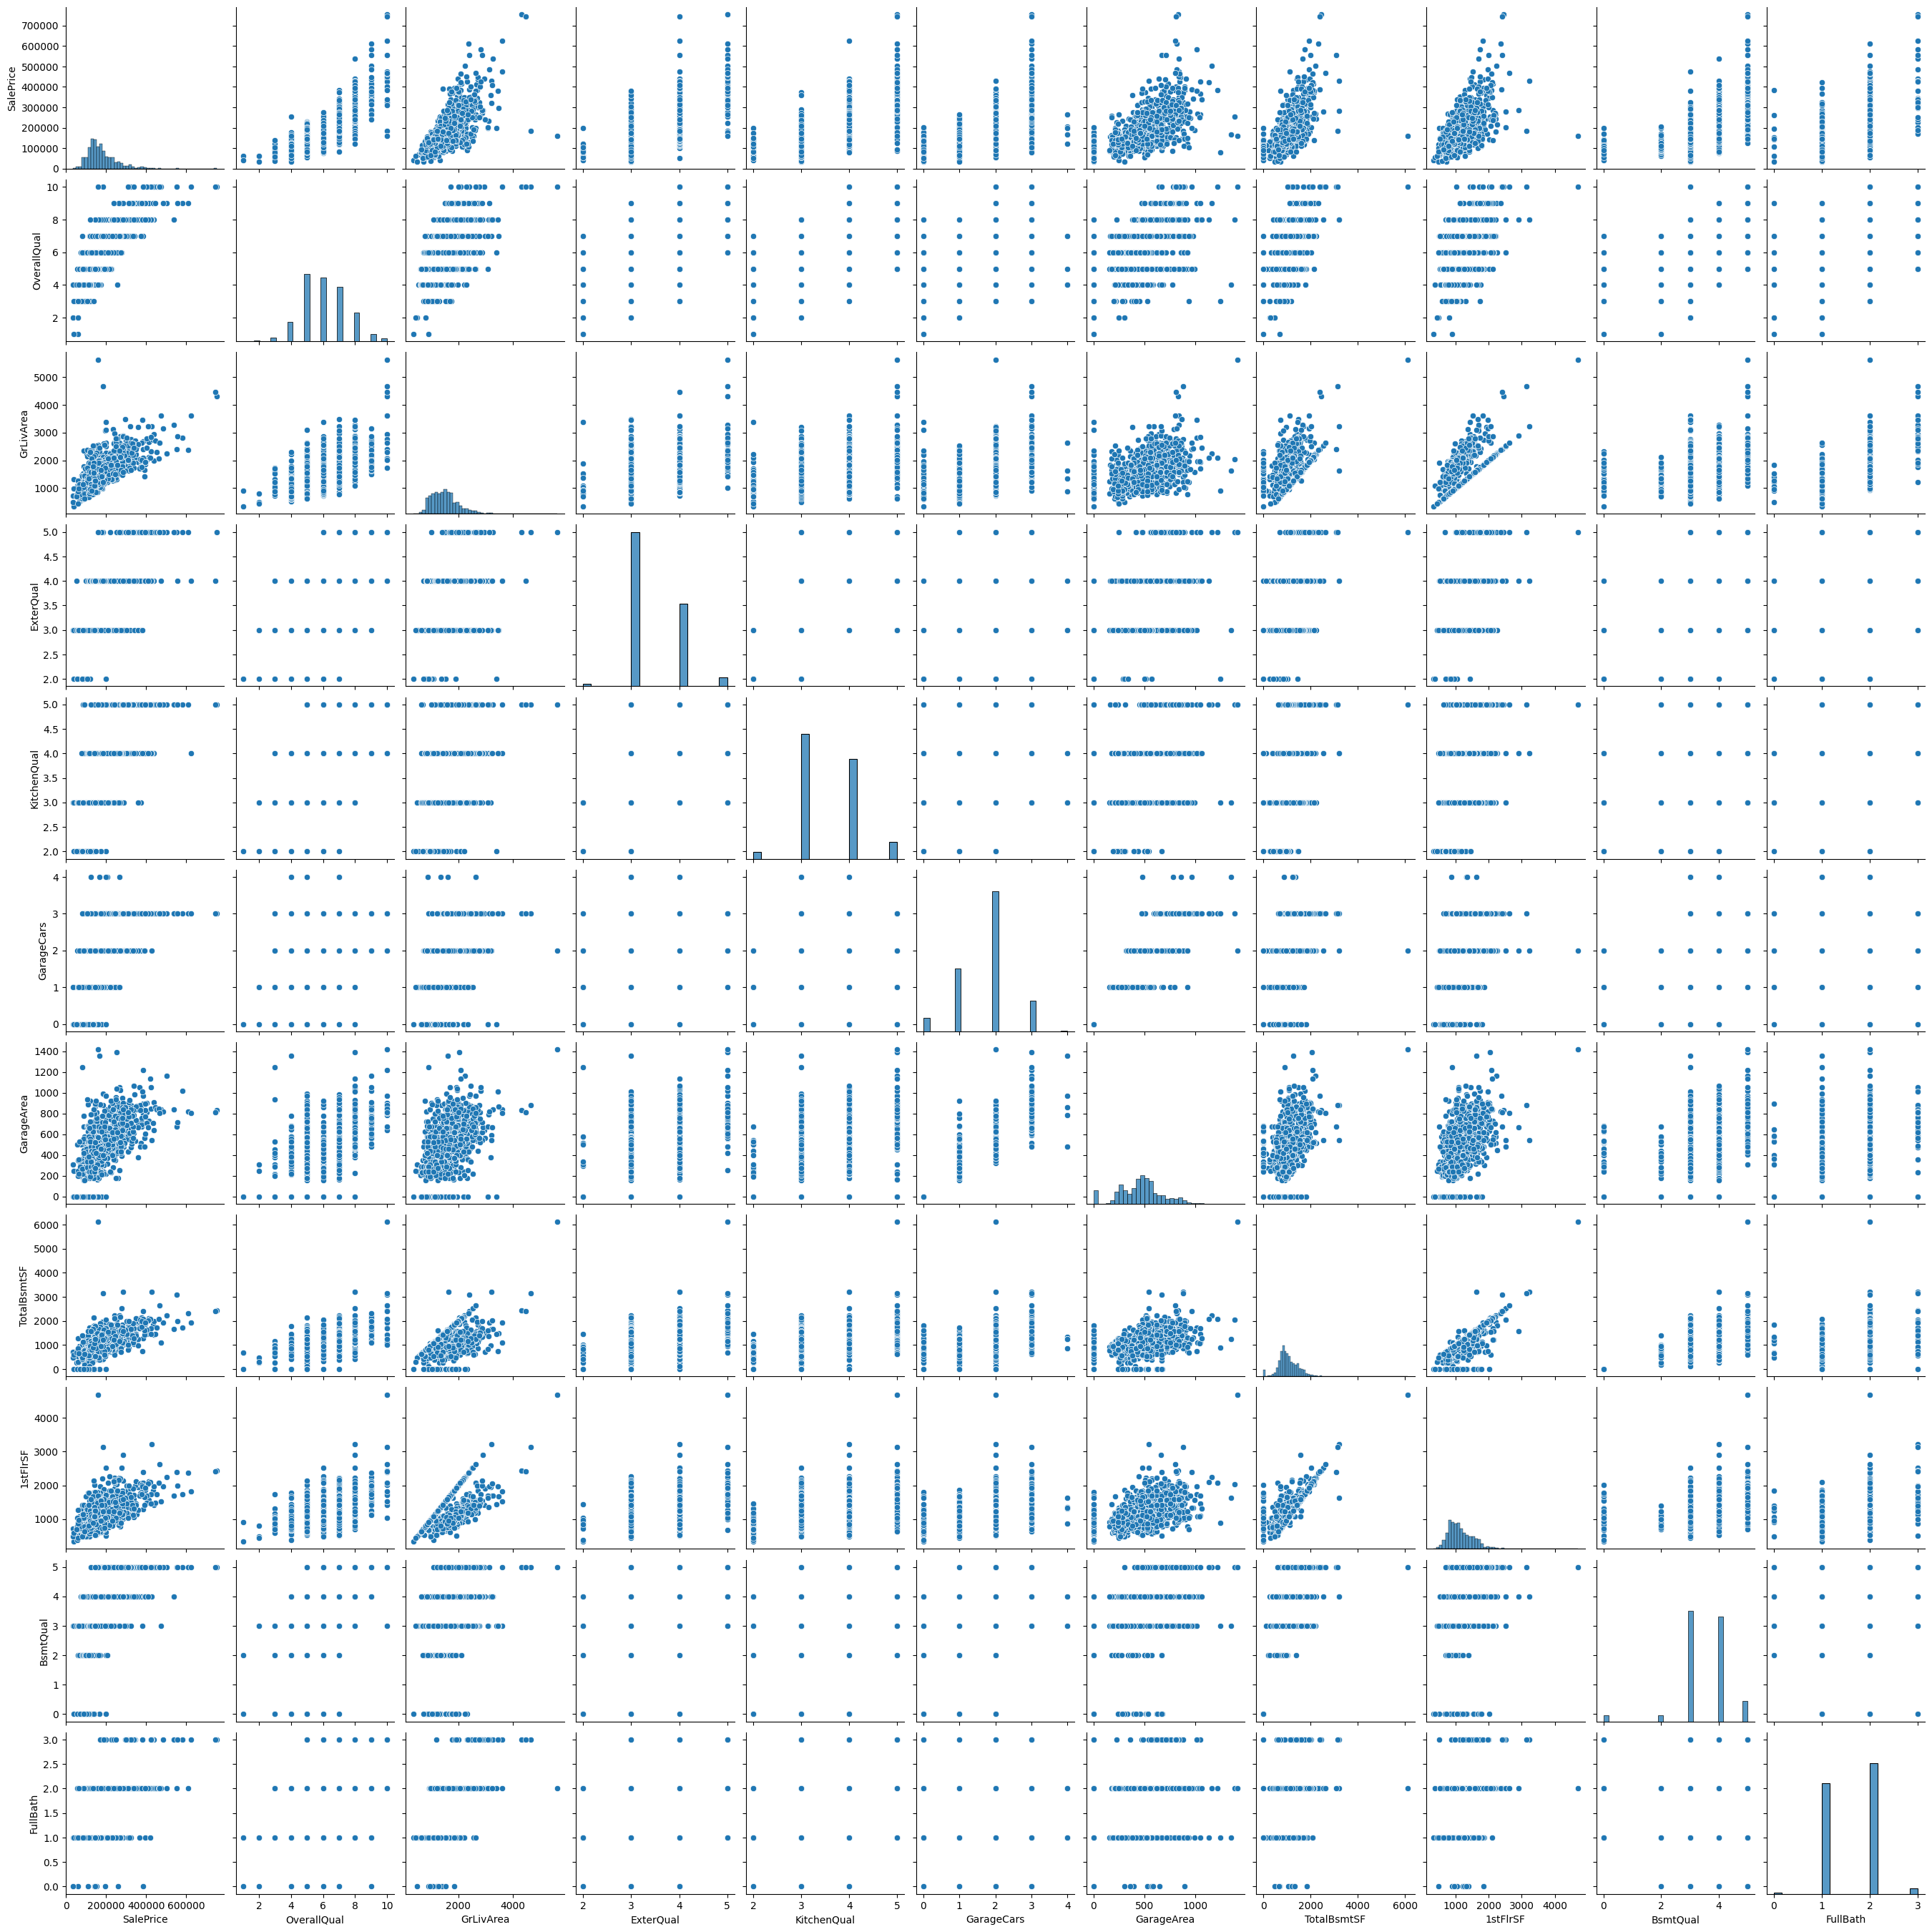

In [28]:
# Get the top 10 features most correlated with 'SalePrice'
top_10_corr_features = corr['SalePrice'].sort_values(ascending=False).head(11).index

# Create a pairplot for these features
sns.pairplot(combined[top_10_corr_features])

### Bivariate Analysis of Target and Caterogical Features

In [29]:
def bi_box_plot(data, categorical_features, target, plot_num_cols=3):
    num_plots = len(categorical_features)
    total_cols = plot_num_cols
    total_rows = num_plots // total_cols + 1

    fig = make_subplots(rows=total_rows, cols=total_cols)

    for i, var in enumerate(categorical_features):
        row = i // total_cols + 1
        pos = i % total_cols + 1
        for category in data[var].unique():
            fig.add_trace(go.Box(y=data[data[var]==category][target], name=str(category)), row=row, col=pos)

    fig.update_layout(height=300*total_rows, width=400*total_cols, title_text="Boxplot of 'SalePrice' for each category")
    fig.show()

In [30]:
bi_box_plot(combined, categorical_cols, 'SalePrice')

# Data Preprocessing
In this section, we are probably going to drop alot of variables. Thus, we can define a update_col function to keep track of which continuous, ordinal and caterogical features we dropped and keep.

In [31]:
features = {}
features['continuous'] = continuous_features
features['ordinal'] = ordinal_features
features['categorical'] = categorical_features

def update_col(features, cols_to_drop):
    features['continuous'] = [col for col in features['continuous'] if col not in cols_to_drop]
    features['ordinal'] = [col for col in features['ordinal'] if col not in cols_to_drop]
    features['categorical'] = [col for col in features['categorical'] if col not in cols_to_drop]
    
    return features

### Removing highly correlated features
It's crucial to address features with high collinearity because they can negatively impact the performance of our regression model. These highly correlated features don't provide additional information and may lead to multicollinearity issues, making it challenging for the model to discern the individual effects of each feature.

By removing these highly correlated features, we not only enhance the interpretability and stability of our regression model but also improve computational efficiency. Additionally, reducing the dimensionality of the dataset helps mitigate the curse of dimensionality, making the model more robust and less prone to overfitting.

 **Highly Correlated variables**:
* ```PoolQC``` and ```PoolArea```
* ```GarageArea``` and ```GarageCars```
* ```GarageCond``` and ```GarageQual```
* ```GarageYrBlt``` and ```YearBuilt```
* ```Fireplaces``` and ```FireplaceQu```
* ```TotRmsAbvGrd``` and ```GrLivArea```
* ```1stFlrSF``` and ```TotalBsmtSF```
* ```BsmtFinSF1``` and ```BsmtFinType1```
* ```BsmtFinSF2``` and ```BsmtFinType2```
* ```OverallQual``` and ```ExterQual```
* ```KitchenQual``` and ```ExterQual```

In [32]:
# Every model used downstream is either L2-regularised (Ridge, BayesianRidge) or a
# tree ensemble (GBR, CatBoost, LightGBM). Neither is harmed by collinearity: the
# penalty handles it for the linear models, and trees are invariant to it. Dropping
# one of each correlated pair therefore throws away real signal for no benefit, so we
# only drop true near-duplicates. In particular '1stFlrSF' is KEPT -- it is needed to
# build TotalSF correctly in the Feature Engineering section.
cols_to_drop = ['GarageCond',    # r ~ 0.95 with GarageQual, effectively the same column
                'GarageYrBlt']   # r ~ 0.83 with YearBuilt, and adds missing values
x_all.drop(cols_to_drop, axis=1, inplace=True)
features = update_col(features, cols_to_drop)
print("Dropped:", cols_to_drop)

Dropped: ['GarageCond', 'GarageYrBlt']


### Removing (almost) constant dominating features 
We remove features that exhibit little to no variability across observations, as they offer minimal discriminatory power and can hinder model performance. In this context, we set a threshold of 95% similarity across observations to identify such features.

In [33]:
def remove_near_constant_features(df, threshold=0.95):
    near_constant = []
    for col in df.columns:
        dominant_val_pct = df[col].value_counts(normalize=True).iloc[0]
        if dominant_val_pct > threshold:
            near_constant.append(col)
    df = df.drop(near_constant, axis=1)
    return df, near_constant

# Apply the function to the numerical columns
x_all_num = x_all.select_dtypes(exclude=['object'])
x_all_num, near_const_num = remove_near_constant_features(x_all_num)
print("Dropping these Numerical Features with >95% of the same value: ", near_const_num)

# Apply the function to the categorical columns
x_all_cat = x_all.select_dtypes(include=['object'])
x_all_cat, near_const_cat = remove_near_constant_features(x_all_cat)
print("Dropping these Categorical Features with >95% of the same value: ", near_const_cat)

# Combine the processed numerical and categorical columns back into one DataFrame
x_all = pd.concat([x_all_num, x_all_cat], axis=1)
features = update_col(features, near_const_num+near_const_cat)

Dropping these Numerical Features with >95% of the same value:  ['Street', 'Utilities', 'LandSlope', 'LowQualFinSF', 'KitchenAbvGr', '3SsnPorch', 'PoolArea', 'PoolQC', 'MiscVal']
Dropping these Categorical Features with >95% of the same value:  ['Condition2', 'RoofMatl', 'Heating']


### Missing values

In [34]:
# Calculate missing data
missing_data = x_all.isnull().sum()
missing_data = missing_data[missing_data > 0]  # Only consider columns with missing data
missing_percentage = (missing_data / len(x_all)) * 100

# Combine the count and percentage into a DataFrame for nicer formatting
missing_df = pd.DataFrame({'Count': missing_data, 'Percentage': missing_percentage})

# Sort by percentage of missing values
missing_df = missing_df.sort_values(by='Percentage', ascending=False)

print("Columns with missing data, their count and percentage:")
print(missing_df)

Columns with missing data, their count and percentage:
              Count  Percentage
MiscFeature    2814   96.402878
MasVnrType     1766   60.500171
LotFrontage     486   16.649538
GarageFinish    159    5.447071
GarageType      157    5.378554
MasVnrArea       23    0.787941
MSZoning          4    0.137033
BsmtFullBath      2    0.068517
BsmtHalfBath      2    0.068517
Functional        2    0.068517
Exterior1st       1    0.034258
Electrical        1    0.034258
Exterior2nd       1    0.034258
GarageCars        1    0.034258
GarageArea        1    0.034258
KitchenQual       1    0.034258
TotalBsmtSF       1    0.034258
BsmtUnfSF         1    0.034258
BsmtFinSF2        1    0.034258
BsmtFinSF1        1    0.034258
SaleType          1    0.034258


We'll drop columns with missing values exceeding 15% rather than removing rows, as the latter would lead to losing a substantial number of observations. Imputing missing values with mean or mode could introduce bias due to the high proportion of missing data. Therefore, dropping these columns helps maintain data integrity and reduces the risk of biased analysis.

In [35]:
# Missing-ness alone is a poor reason to discard a column. Three groups here:
#
#   1. NA means "the feature is absent", not "unknown": MasVnrType (no veneer),
#      GarageType / GarageFinish (no garage). Filling with the literal category "None"
#      is a deterministic mapping -- no statistic is estimated, so it cannot leak.
#   2. LotFrontage (16.6% missing) is genuinely predictive and strongly determined by
#      neighbourhood. It is imputed with the per-Neighborhood median, fit inside the
#      model pipeline (see NeighborhoodMedianImputer in the Modelling section).
#   3. MasVnrArea is 0.8% missing -- dropping it was never justifiable. Median imputed
#      in the pipeline like every other continuous column.
#
# Only MiscFeature is actually dropped: 96.4% missing, and its companion MiscVal was
# already removed as near-constant.
absent_means_none = [c for c in ['MasVnrType', 'GarageType', 'GarageFinish'] if c in x_all.columns]
x_all[absent_means_none] = x_all[absent_means_none].fillna('None')
print(f"Filled with the category 'None' (absence, not missingness): {absent_means_none}")

cols_to_drop = [c for c in ['MiscFeature'] if c in x_all.columns]
x_all = x_all.drop(cols_to_drop, axis=1)
features = update_col(features, cols_to_drop)
print(f"Dropped: {cols_to_drop}")
print(f"Kept (was previously dropped): LotFrontage, MasVnrArea, MasVnrType, GarageType, GarageFinish")

Filled with the category 'None' (absence, not missingness): ['MasVnrType', 'GarageType', 'GarageFinish']
Dropped: ['MiscFeature']
Kept (was previously dropped): LotFrontage, MasVnrArea, MasVnrType, GarageType, GarageFinish


In [36]:
# NOTE: imputation deliberately does NOT happen here any more.
#
# Previously this cell called `fit_transform` on all of `x_all` (train + test) once,
# outside every pipeline. That fits the imputation statistics on rows that later became
# the validation and test sets, and it is inconsistent with the ColumnTransformer below
# -- which carefully refits the scaler/encoders on every CV fold.
#
# Imputation is now a step inside the ColumnTransformer (see the Modelling section), so
# it is refit per fold like every other transformer. Missing values are left in place
# until then; the few diagnostic cells that cannot tolerate NaN impute a local, train-only
# copy for display purposes.
print(f"Columns still containing missing values (imputed inside the pipeline): "
      f"{int((x_all.isnull().sum() > 0).sum())}")

Columns still containing missing values (imputed inside the pipeline): 17


In [37]:
missing_after = x_all.isnull().sum()
print(missing_after[missing_after > 0].sort_values(ascending=False))

LotFrontage     486
MasVnrArea       23
MSZoning          4
BsmtFullBath      2
BsmtHalfBath      2
Functional        2
GarageArea        1
Electrical        1
Exterior2nd       1
Exterior1st       1
KitchenQual       1
GarageCars        1
TotalBsmtSF       1
BsmtUnfSF         1
BsmtFinSF2        1
BsmtFinSF1        1
SaleType          1
dtype: int64


# Outliers
Outliers are unusual values in the dataset, and they can distort statistical analysis and violate their assumptions. For this reason, outlier detection and removal is usually performed before feature engineering and selection. Outliers can have many causes, such as data collection errors, data corruption, or true outlier observation - take for example, Micheal Jordan. 

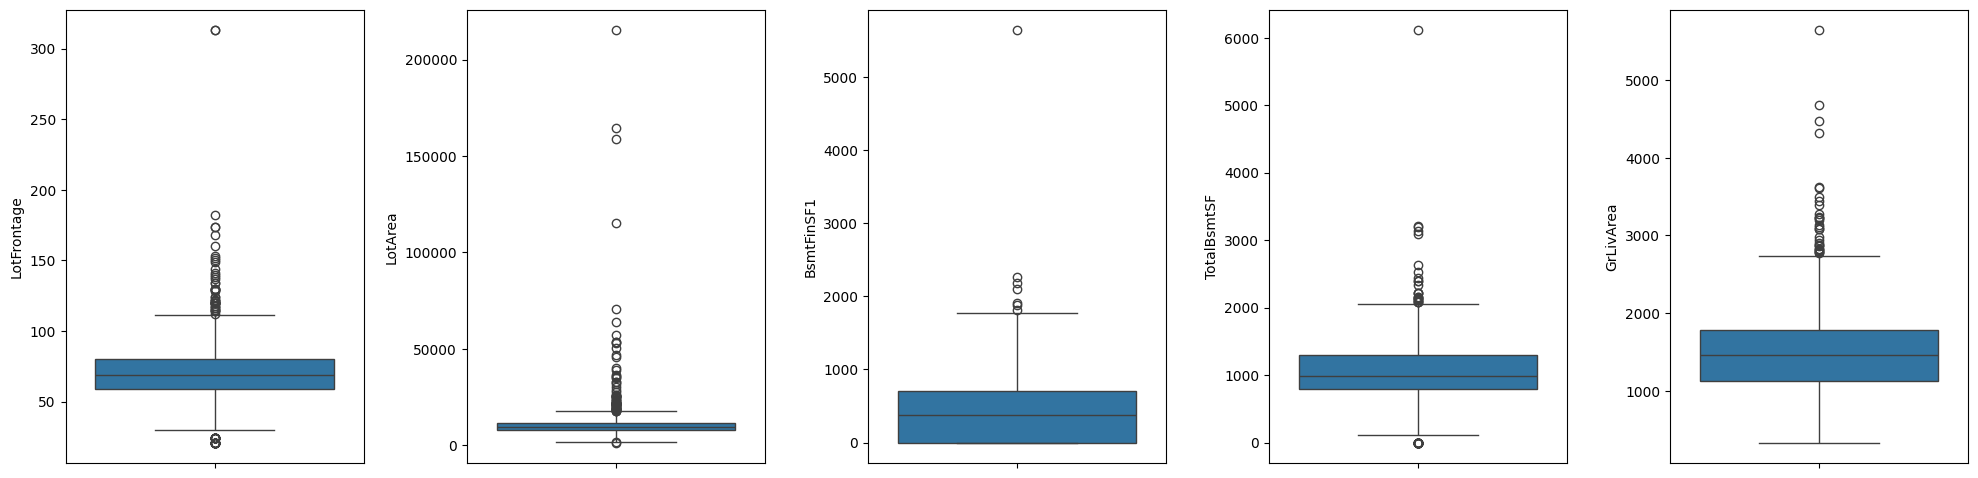

In [38]:
out_col = ['LotFrontage','LotArea','BsmtFinSF1','TotalBsmtSF','GrLivArea']
fig = plt.figure(figsize=(20,5))
for index,col in enumerate(out_col):
    plt.subplot(1,5,index+1)
    sns.boxplot(y=col, data=raw_train)
fig.tight_layout(pad=1.5)

In [39]:
# Record WHICH training rows are outliers, but do not drop them yet.
#
# Previously these rows were dropped from `train` before the train/validation split,
# which meant the validation set also had its hard cases deleted -- an optimistic
# estimate, because at inference time you cannot drop rows you find inconvenient.
# The mask is applied to the TRAINING SPLIT ONLY, after splitting (Modelling section).
outlier_mask = (
    (raw_train['LotFrontage'] > 200)
    | (raw_train['LotArea'] > 100000)
    | (raw_train['BsmtFinSF1'] > 4000)
    | (raw_train['TotalBsmtSF'] > 5000)
    | (raw_train['GrLivArea'] > 4000)
)
outlier_idx = raw_train.index[outlier_mask]
print(f"{len(outlier_idx)} outlier rows flagged; they will be removed from the training split only.")

9 outlier rows flagged; they will be removed from the training split only.


# Feature Engineering

### Creating New Features

In [40]:
def sum_present(df, cols):
    """Sum only the columns that still exist (earlier steps may have dropped some)."""
    present = [c for c in cols if c in df.columns]
    return df[present].sum(axis=1), present


def register_col(features, group, cols):
    """Add newly created columns to a feature group.

    `update_col` only ever REMOVES names. Without a matching 'register' step the new
    engineered columns never entered features['continuous'], so the ColumnTransformer
    below (remainder='drop' by default) silently discarded all of them -- while their
    source columns had already been dropped. The net effect was losing nine real
    predictors and gaining nothing.
    """
    features[group] = features[group] + [c for c in cols if c not in features[group]]
    return features


# --- create the aggregate features ---
x_all['TotalBsmtFin'], used_bsmtfin = sum_present(x_all, ['BsmtFinSF1', 'BsmtFinSF2'])

# TotalSF must include the FIRST floor. The original omitted '1stFlrSF' (it had been
# dropped as collinear), so "total square footage" was missing an entire storey.
x_all['TotalSF'], used_sf = sum_present(x_all, ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF'])

# Half bathrooms count as half, and basement bathrooms count too.
bath_parts = {'FullBath': 1.0, 'HalfBath': 0.5, 'BsmtFullBath': 1.0, 'BsmtHalfBath': 0.5}
used_bath = [c for c in bath_parts if c in x_all.columns]
x_all['TotalBath'] = sum(x_all[c] * bath_parts[c] for c in used_bath)

x_all['TotalPorch'], used_porch = sum_present(
    x_all, ['OpenPorchSF', 'EnclosedPorch', 'ScreenPorch', '3SsnPorch', 'WoodDeckSF'])

# Age at point of sale is a more direct parametrisation than the raw calendar years:
# a 1998 house sold in 2006 and a 2002 house sold in 2010 are the same 8-year-old house.
if {'YrSold', 'YearBuilt'} <= set(x_all.columns):
    x_all['HouseAge'] = x_all['YrSold'] - x_all['YearBuilt']
if {'YrSold', 'YearRemodAdd'} <= set(x_all.columns):
    x_all['RemodAge'] = x_all['YrSold'] - x_all['YearRemodAdd']

new_features = ['TotalBsmtFin', 'TotalSF', 'TotalBath', 'TotalPorch', 'HouseAge', 'RemodAge']

# --- drop the source columns, then REGISTER the new ones ---
# YrSold is kept; YearBuilt/YearRemodAdd are now fully captured by the age features.
cols_to_drop = sorted(set(used_bsmtfin + used_sf + used_bath + used_porch + ['YearBuilt', 'YearRemodAdd']))
x_all.drop(columns=cols_to_drop, inplace=True)
features = update_col(features, cols_to_drop)
features = register_col(features, 'continuous', new_features)

print(f"Consumed {len(cols_to_drop)} source columns: {cols_to_drop}")
print(f"Registered {len(new_features)} engineered features as continuous: {new_features}")

Consumed 15 source columns: ['1stFlrSF', '2ndFlrSF', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtFullBath', 'BsmtHalfBath', 'EnclosedPorch', 'FullBath', 'HalfBath', 'OpenPorchSF', 'ScreenPorch', 'TotalBsmtSF', 'WoodDeckSF', 'YearBuilt', 'YearRemodAdd']
Registered 6 engineered features as continuous: ['TotalBsmtFin', 'TotalSF', 'TotalBath', 'TotalPorch', 'HouseAge', 'RemodAge']


### Target Variable Transformation

In [41]:
log_transformed_salesprice = np.log1p(y_train["SalePrice"])

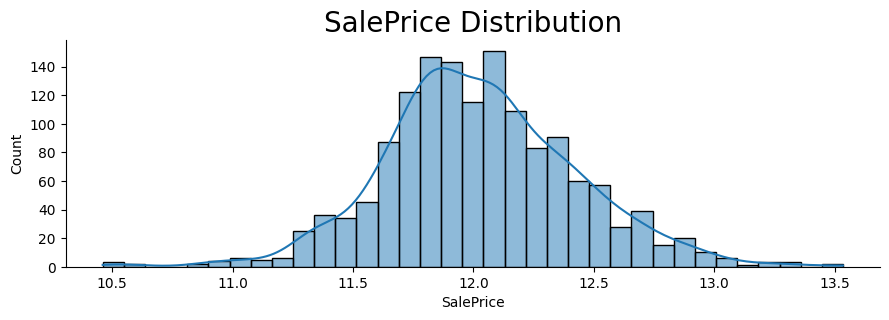

In [42]:
sns.displot(log_transformed_salesprice, kde=True, height=3, aspect=3)
plt.title('{} Distribution'.format('SalePrice'), fontsize=20)
plt.show()

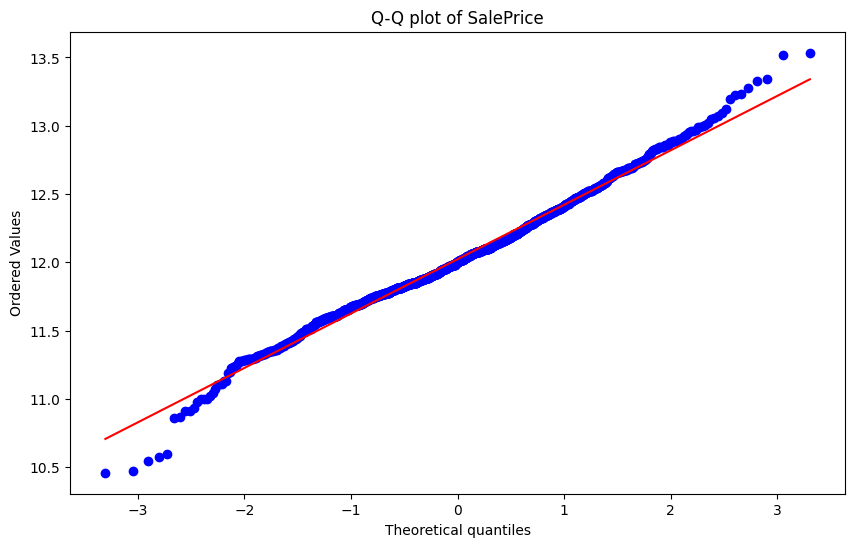

In [43]:
# Q-Q plot
plt.figure(figsize=(10, 6))
scipy.stats.probplot(log_transformed_salesprice, dist="norm", plot=plt)
plt.title('Q-Q plot of SalePrice')
plt.show()

## Feature Selection

In [44]:
def feature_selection_continuous(df, target_var, continuous_features):
    # Prepare the data
    target = df[target_var]
    df2 = df.drop([target_var], axis=1)

    # Select the numerical dataframe
    numeric_df = df2[continuous_features]

    # SelectKBest with f_regression
    selector_f_regression = SelectKBest(f_regression, k='all')
    selector_f_regression.fit_transform(numeric_df, target)
    scores_f_regression = selector_f_regression.scores_

    # Calculate Pearson's correlation coefficient for each feature
    scores_corr = numeric_df.corrwith(target)

    # Print the scores in a more readable format
    print("\nF_regression scores:")
    for score, fname in sorted(zip(scores_f_regression, continuous_features), reverse=True):
        print(f"{fname}: {score}")

    print("\nCorrelation scores:")
    for score, fname in sorted(zip(scores_corr, continuous_features), reverse=True):
        print(f"{fname}: {score}")

# Retrieve the train rows only -- the target is never involved for test rows.
x_train = x_all.loc[train.index]
y_train = y_train.loc[train.index]

assert x_train.shape[0] == y_train.shape[0], "Number of rows in x_train and y_train do not match"
combined = pd.concat([x_train, y_train], axis=1)

# These scores are DIAGNOSTIC ONLY -- nothing below drops features based on them.
# f_regression / mutual_info cannot accept NaN, and imputation now lives inside the
# model pipeline, so build a local train-only imputed copy purely for scoring.
combined_diag = combined.copy()
for col in features['continuous']:
    combined_diag[col] = combined_diag[col].fillna(combined_diag[col].median())
for col in features['ordinal'] + features['categorical']:
    mode = combined_diag[col].mode()
    if len(mode):
        combined_diag[col] = combined_diag[col].fillna(mode.iloc[0])

# Call the functions
feature_selection_continuous(combined_diag, 'SalePrice', features['continuous'])


F_regression scores:
TotalSF: 2299.061789995098
GrLivArea: 1470.5850099552842
TotalBath: 968.2964291120168
GarageArea: 926.951287273264
HouseAge: 549.9758772537205
RemodAge: 510.0393686584282
MasVnrArea: 419.32846833907763
TotalPorch: 254.46835812347533
TotalBsmtFin: 225.98386095186612
LotFrontage: 184.02414900789805
LotArea: 109.0903551234761
BsmtUnfSF: 70.3039481063848
YrSold: 1.2206613325301774

Correlation scores:
TotalSF: 0.782260052797984
GrLivArea: 0.7086244776126521
TotalBath: 0.6317310679319874
GarageArea: 0.6234314389183617
MasVnrArea: 0.4726144990045739
TotalPorch: 0.3854833424591181
TotalBsmtFin: 0.36632769193495623
LotFrontage: 0.33477085313975996
LotArea: 0.2638433538714057
BsmtUnfSF: 0.2144791055469689
YrSold: -0.028922585168730284
RemodAge: -0.5090787380156293
HouseAge: -0.5233504175468159


In [45]:
def feature_selection_categorical(df, target_var, categorical_features):
    # Prepare the data
    target = df[target_var]
    df = df.drop([target_var], axis=1)

    # Select the categorical dataframe
    categorical_df = df[categorical_features]

    # Check if the data is already encoded
    if categorical_df.applymap(np.isreal).all().all():
        categorical_df_encoded = categorical_df
    else:
        # Create a copy of the dataframe to avoid changing the original data
        categorical_df_encoded = categorical_df.copy()

        # Apply LabelEncoder to each column in the dataframe
        for column in categorical_df_encoded.columns:
            le = LabelEncoder()
            categorical_df_encoded[column] = le.fit_transform(categorical_df_encoded[column])

    # SelectKBest with mutual_info_regression
    selector_mutual_info_regression = SelectKBest(mutual_info_regression, k='all')
    selector_mutual_info_regression.fit_transform(categorical_df_encoded, target)
    scores_mutual_info_regression = selector_mutual_info_regression.scores_

    # Print the scores in a more readable format
    print("\nMutual_info_regression scores:")
    for score, fname in sorted(zip(scores_mutual_info_regression, categorical_df_encoded.columns), reverse=True):
        print(f"{fname}: {score}")
        
feature_selection_categorical(combined_diag, 'SalePrice', features['categorical'])


Mutual_info_regression scores:
Neighborhood: 0.5082497905150292
MSSubClass: 0.2721556429370886
GarageFinish: 0.26420674356848695
GarageType: 0.2056503232931921
Foundation: 0.1901023359368419
Exterior2nd: 0.16593720633095987
Exterior1st: 0.13453202350807514
MSZoning: 0.11740162998411297
SaleCondition: 0.0865797978538081
MasVnrType: 0.08376936247612066
HouseStyle: 0.08289623010496383
Electrical: 0.059951512139613916
CentralAir: 0.053368355858743444
SaleType: 0.0471070962121618
BldgType: 0.04636667090754254
LandContour: 0.03475214127879189
Condition1: 0.023919603990426586
RoofStyle: 0.014881322236453665
LotConfig: 0.010769617560126843
MoSold: 0.0


In [46]:
feature_selection_categorical(combined_diag, 'SalePrice', features['ordinal'])


Mutual_info_regression scores:
OverallQual: 0.5637739717823331
GarageCars: 0.35970967387036135
ExterQual: 0.33940718775466516
KitchenQual: 0.33770950516187637
BsmtQual: 0.3226068511794029
TotRmsAbvGrd: 0.22036117640194686
FireplaceQu: 0.21534203663520213
Fireplaces: 0.1695440455958157
HeatingQC: 0.15708469882355258
BsmtFinType1: 0.14366152951497524
OverallCond: 0.11617567719215094
BsmtExposure: 0.08513339430425626
GarageQual: 0.07420639114498528
LotShape: 0.07154133921829153
BedroomAbvGr: 0.07001026105059482
PavedDrive: 0.053248939718569144
Fence: 0.04108540320322174
BsmtCond: 0.038247799917098924
BsmtFinType2: 0.037130810673997816
Alley: 0.030775370691711768
ExterCond: 0.016265182571483905
Functional: 0.013908104311377123


# Quick Model Scoping with pycaret

In [47]:
from pycaret.regression import *

In [48]:
ordinal_features = {}

for feature in features['ordinal']:
    # Get unique values for the feature
    unique_values = sorted(pd.Series(combined_diag[feature].unique()).dropna().tolist())
    
    # Check if all unique values are integers (when converted from float)
    non_integer_values = [value for value in unique_values if not float(value).is_integer()]
    
    if non_integer_values:
        print(f"Feature {feature} contains non-integer values: {non_integer_values}")
    else:
        # Convert the unique values to integers and add the feature to the dictionary
        ordinal_features[feature] = [int(value) for value in unique_values]
        
exp1 = setup(combined_diag, 
             target='SalePrice', 
             numeric_features=features['continuous'], 
             categorical_features=features['categorical'],
             ordinal_features=ordinal_features,
             transform_target = True,
             transform_target_method = 'yeo-johnson',
             #transformation = True,
             #transformation_method='yeo-johnson',
             normalize = True,
             normalize_method = 'zscore',#'robust',
            #  feature_selection=True,
            #  feature_selection_method='univariate',
            #  n_features_to_select= 0.8,
            #  remove_multicollinearity = True,
            #  multicollinearity_threshold = 0.8,
            #  pca = True,
            #  pca_method='linear',
            #  pca_components=0.7,
            #  low_variance_threshold= 0.8,
             session_id=123)

,Description,Value
0,Session id,123
1,Target,SalePrice
2,Target type,Regression
3,Original data shape,"(1460, 56)"
4,Transformed data shape,"(1460, 201)"
5,Transformed train set shape,"(1021, 201)"
6,Transformed test set shape,"(439, 201)"
7,Ordinal features,22
8,Numeric features,13
9,Categorical features,20


In [49]:
# Compare machine learning models
best = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,14979.5027,807952531.0972,27272.1866,0.8838,0.1250,0.0860,0.5540
gbr,Gradient Boosting Regressor,16248.0710,847560006.1382,28142.6849,0.8767,0.1320,0.0929,0.1240
lightgbm,Light Gradient Boosting Machine,16918.7830,933375687.6670,29317.1218,0.8650,0.1373,0.0962,0.3080
et,Extra Trees Regressor,17329.0423,1008115351.8534,30541.6406,0.8543,0.1378,0.0975,0.2230
rf,Random Forest Regressor,18202.5685,1088270025.1099,31710.0958,0.8433,0.1466,0.1047,0.2190
ada,AdaBoost Regressor,23690.0991,1324745961.0683,35737.3972,0.8018,0.1756,0.1332,0.0950
dt,Decision Tree Regressor,26373.4573,1998001521.8246,42920.5694,0.7118,0.2108,0.1549,0.0480
knn,K Neighbors Regressor,26669.2359,1974577335.2175,43525.5225,0.7059,0.2095,0.1513,0.0540
br,Bayesian Ridge,18704.5851,3005704051.6415,41447.3763,0.5542,0.1501,0.1068,0.0490
par,Passive Aggressive Regressor,32230.5717,3093432083.7836,51044.9798,0.5477,0.2463,0.1863,0.0450


# Modelling

In [50]:
# Standard library imports
import os
from math import sqrt
import itertools

# Third party imports
from numpy import log1p, exp
from scipy.special import inv_boxcox, boxcox1p, inv_boxcox1p
from scipy.stats import yeojohnson
from scipy.optimize import nnls

# Scikit-learn imports for preprocessing and transformation
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler
from sklearn.preprocessing import QuantileTransformer, PowerTransformer, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Scikit-learn imports for models
from sklearn.linear_model import Ridge, BayesianRidge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor, StackingRegressor

# Other model imports
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# Scikit-learn imports for model selection and evaluation
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV, train_test_split,
                                     KFold, cross_val_predict)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone, BaseEstimator, TransformerMixin

In [51]:
x = x_all.loc[train.index]
y = y_train.loc[train.index]['SalePrice']          # Series: avoids column-vector warnings
X_test_final = x_all.loc[test.index]               # renamed so re-running this cell is safe

X_train, X_val, Y_train, Y_val = train_test_split(x, y, test_size=0.2, random_state=42)

# Outliers are removed from the TRAINING SPLIT ONLY. Removing them before the split
# (as the original did) also cleans the validation set, which flatters the score.
n_before = len(X_train)
keep = ~X_train.index.isin(outlier_idx)
X_train, Y_train = X_train.loc[keep], Y_train.loc[keep]

# Shared evaluation protocol
N_ITER = 100
CV = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train split : {n_before} rows -> {X_train.shape[0]} rows after removing "
      f"{n_before - X_train.shape[0]} outliers, {X_train.shape[1]} columns")
print(f"Val split   : {X_val.shape[0]} rows (untouched: outliers kept, never used for fitting anything)")
print(f"Test        : {X_test_final.shape[0]} rows")

Train split : 1168 rows -> 1160 rows after removing 8 outliers, 55 columns
Val split   : 292 rows (untouched: outliers kept, never used for fitting anything)
Test        : 1459 rows


In [52]:
# The Kaggle metric for this competition is RMSLE -- RMSE on log(SalePrice).
# Using the log transform makes the in-CV objective (neg MSE on the transformed target)
# numerically identical to MSLE, so tuning, model selection and the reported score all
# optimise the same thing. Box-Cox with a hardcoded lambda=0.15 is only an approximation
# of that, and the original then REPORTED dollar-RMSE, a third different objective.
transformation_method = "log"

if transformation_method == "log":
    transformer = FunctionTransformer(func=log1p, inverse_func=exp, validate=True)
elif transformation_method == "yeojohnson":
    transformer = PowerTransformer(method='yeo-johnson')
elif transformation_method == "boxcox":
    transformer = FunctionTransformer(func=lambda x: boxcox1p(x, 0.15), inverse_func=lambda x: inv_boxcox1p(x, 0.15), validate=True)
elif transformation_method == "quantile":
    transformer = QuantileTransformer(output_distribution='uniform', random_state=0)
elif transformation_method == "none":
    transformer = FunctionTransformer(func=lambda x: x, inverse_func=lambda x: x, validate=True)
else:
    raise ValueError(f"Unknown transformation method: {transformation_method}")

SUBMISSION_DIR = PROJECT_ROOT / 'house_prices_advanced_regression_techniques' / 'submission'
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

In [53]:
def rmsle(y_truth, y_pred):
    """Root mean squared log error -- the metric this Kaggle competition is scored on."""
    y_pred = np.clip(np.asarray(y_pred, dtype=float).ravel(), 1, None)
    y_truth = np.asarray(y_truth, dtype=float).ravel()
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_truth)) ** 2)))


def evaluate_model(y_pred, y_truth, verbose=True):
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    y_truth = np.asarray(y_truth, dtype=float).ravel()

    mae = mean_absolute_error(y_truth, y_pred)
    mse = mean_squared_error(y_truth, y_pred)
    rmse = sqrt(mse)
    r2 = r2_score(y_truth, y_pred)
    msle = rmsle(y_truth, y_pred)

    if verbose:
        print(f'RMSLE: {msle:.5f}   <- competition metric')
        print(f'MAE:   {mae:,.2f}')
        print(f'RMSE:  {rmse:,.2f}')
        print(f'R2:    {r2:.4f}')

    return {'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2, 'rmsle': msle}


def capped_n_iter(param_dict, n_iter=None):
    """RandomizedSearchCV errors/warns when n_iter exceeds the size of a discrete grid."""
    total = 1
    for v in param_dict.values():
        total *= len(v)
    return int(min(n_iter or N_ITER, total))


results = {}   # empty dictionary to store the results

In [54]:
class NeighborhoodMedianImputer(BaseEstimator, TransformerMixin):
    """Impute LotFrontage with the median of its Neighborhood.

    Lot frontage is largely determined by the street layout of a neighbourhood, so the
    neighbourhood median is a far better estimate than a global one. The medians are
    LEARNED, so this must be fit per CV fold -- hence a transformer inside the pipeline
    rather than a one-off pass over the whole frame.
    """

    def __init__(self, target_col='LotFrontage', group_col='Neighborhood'):
        self.target_col = target_col
        self.group_col = group_col

    def fit(self, X, y=None):
        self.active_ = self.target_col in X.columns and self.group_col in X.columns
        if self.active_:
            self.medians_ = X.groupby(self.group_col)[self.target_col].median()
            self.global_median_ = X[self.target_col].median()
        return self

    def transform(self, X):
        if not self.active_:
            return X
        X = X.copy()
        fill = X[self.group_col].map(self.medians_).fillna(self.global_median_)
        X[self.target_col] = X[self.target_col].fillna(fill)
        return X


# Imputation and skew correction both live INSIDE the ColumnTransformer, so both are
# refit on every CV fold. PowerTransformer(yeo-johnson) replaces StandardScaler: it
# corrects the heavy right skew in LotArea, GrLivArea, TotalSF etc. and standardises in
# the same step, and unlike log1p it tolerates the zeros in TotalPorch and the negative
# values RemodAge can take.
numeric_transformer = make_pipeline(SimpleImputer(strategy='median'),
                                    PowerTransformer(method='yeo-johnson', standardize=True))
categorical_transformer = make_pipeline(SimpleImputer(strategy='most_frequent'),
                                        OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
ordinal_transformer = make_pipeline(SimpleImputer(strategy='most_frequent'),
                                    OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))

# --- integrity guard -------------------------------------------------------------
# ColumnTransformer defaults to remainder='drop'. Any column missing from these three
# lists is silently discarded before every model -- which is exactly how the engineered
# features used to disappear. Fail loudly instead.
covered = set(features['continuous']) | set(features['categorical']) | set(features['ordinal'])
uncovered = set(x_all.columns) - covered
stale = covered - set(x_all.columns)
assert not uncovered, f"Columns not covered by the preprocessor (would be silently dropped): {sorted(uncovered)}"
assert not stale, f"Feature lists reference columns that no longer exist: {sorted(stale)}"
print(f"Preprocessor covers all {len(covered)} columns "
      f"({len(features['continuous'])} continuous, {len(features['categorical'])} categorical, "
      f"{len(features['ordinal'])} ordinal)")

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features['continuous']),
        ('cat', categorical_transformer, features['categorical']),
        ('ord', ordinal_transformer, features['ordinal'])
    ])

def build_pipeline(model):
    """Every model gets the same front end: neighbourhood imputation, then preprocessing.

    Using a factory keeps the LotFrontage imputer from being accidentally omitted from
    one model's pipeline, and leaves the estimator's step name (and therefore the
    param-grid prefixes) unchanged.
    """
    # No `memory=` cache here: joblib.Memory hashes each pipeline step to build its
    # cache key, and it cannot hash a transformer class defined in the notebook itself
    # (NeighborhoodMedianImputer), which makes every fit in a search fail. The fits are
    # cheap enough that the cache was not buying much anyway.
    return make_pipeline(NeighborhoodMedianImputer(), preprocessor, model)

Preprocessor covers all 55 columns (13 continuous, 20 categorical, 22 ordinal)


### Bayesian Ridge

In [55]:
# Bayesian Ridge Regression
bayesian_ridge = BayesianRidge()
bayesian_ridge_pipeline = build_pipeline(bayesian_ridge)
bayesian_ridge_params = {
    'bayesianridge__alpha_1' : [1e-7, 1e-6, 1e-5, 1e-4],
    'bayesianridge__alpha_2' : [1e-7, 1e-6, 1e-5, 1e-4],
    'bayesianridge__lambda_1' : [1e-7, 1e-6, 1e-5, 1e-4],
    'bayesianridge__lambda_2' : [1e-7, 1e-6, 1e-5, 1e-4],
    'bayesianridge__max_iter' : [100, 200, 300, 400, 500]
}

random_search = RandomizedSearchCV(estimator=bayesian_ridge_pipeline, 
                                   param_distributions=bayesian_ridge_params, 
                                   n_iter=capped_n_iter(bayesian_ridge_params), 
                                   cv=5, 
                                   n_jobs=-1, 
                                   refit=True, 
                                   scoring="neg_mean_squared_error")

regr_bayesian_ridge = TransformedTargetRegressor(regressor=random_search, transformer=transformer)
regr_bayesian_ridge.fit(X_train, Y_train)

Y_pred = regr_bayesian_ridge.predict(X_val)
results["bayesian_ridge"] = evaluate_model(Y_pred, Y_val)

RMSLE: 0.12387   <- competition metric
MAE:   14,624.20
RMSE:  23,612.47
R2:    0.9273


### Ridge Regression

In [56]:
# Ridge Regression
ridge = Ridge()
ridge_pipeline = build_pipeline(ridge)
ridge_params = {
    'ridge__alpha' : [0.1, 0.5, 1.0, 2.0, 5.0],
    'ridge__solver' : ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
}

random_search = RandomizedSearchCV(estimator=ridge_pipeline, 
                                   param_distributions=ridge_params, 
                                   n_iter=capped_n_iter(ridge_params), 
                                   cv=5, 
                                   n_jobs=-1, 
                                   refit=True, 
                                   scoring="neg_mean_squared_error")

regr_ridge = TransformedTargetRegressor(regressor=random_search, transformer=transformer)
regr_ridge.fit(X_train, Y_train)

Y_pred = regr_ridge.predict(X_val)
results["ridge"] = evaluate_model(Y_pred, Y_val)

RMSLE: 0.12229   <- competition metric
MAE:   14,613.84
RMSE:  23,523.16
R2:    0.9279


### CatBoost

In [57]:
catboost = CatBoostRegressor(logging_level='Silent')

catboost_pipeline = build_pipeline(catboost)

catboost_params = {
    'catboostregressor__n_estimators' : [100, 300, 500, 1000, 1300, 1600],
    'catboostregressor__learning_rate' : [0.0001, 0.001, 0.01, 0.1],
    'catboostregressor__l2_leaf_reg' : [0.001, 0.01, 0.1],
    'catboostregressor__random_strength' : [0.25, 0.5 ,1],
    'catboostregressor__max_depth' : [3, 6, 9],
    'catboostregressor__min_child_samples' : [2, 5, 10, 15, 20],
    'catboostregressor__rsm' : [0.5, 0.7, 0.9],
    'catboostregressor__bagging_temperature' : [0, 0.5, 1],
    'catboostregressor__border_count' : [32, 64, 128, 255]
}
random_search = RandomizedSearchCV(estimator=catboost_pipeline, 
                                   param_distributions=catboost_params, 
                                   n_iter=capped_n_iter(catboost_params), 
                                   cv=5, 
                                   n_jobs=-1, 
                                   refit=True, 
                                   scoring="neg_mean_squared_error")

regr_catboost = TransformedTargetRegressor(regressor=random_search, transformer=transformer)
regr_catboost.fit(X_train, Y_train)  

Y_pred = regr_catboost.predict(X_val)
results["catboost"] = evaluate_model(Y_pred, Y_val)

RMSLE: 0.12638   <- competition metric
MAE:   14,275.94
RMSE:  25,372.51
R2:    0.9161


### GradientBoosting

In [58]:
gbr = GradientBoostingRegressor(n_estimators=3000, 
                                learning_rate=0.05,
                                max_depth=4,
                                max_features='sqrt',
                                min_samples_leaf=15,
                                min_samples_split=10, 
                                loss='huber',
                                random_state =5)

gbr_pipeline = build_pipeline(gbr)

gbr_params = {
    'gradientboostingregressor__learning_rate' : [0.01, 0.1, 0.15, 0.3, 0.5],
    'gradientboostingregressor__n_estimators' : [100, 500, 1000, 2000, 3000],
    'gradientboostingregressor__max_depth' : [3, 6, 9],
    'gradientboostingregressor__min_samples_split' : [2, 5, 10],
    'gradientboostingregressor__min_samples_leaf' : [1, 2, 5]
}

random_search = RandomizedSearchCV(estimator=gbr_pipeline, 
                                   param_distributions=gbr_params, 
                                   n_iter=capped_n_iter(gbr_params), 
                                   cv=5, 
                                   n_jobs=-1, 
                                   refit=True, 
                                   scoring="neg_mean_squared_error")

regr_gbr = TransformedTargetRegressor(regressor=random_search, transformer=transformer)
regr_gbr.fit(X_train, Y_train)

Y_pred = regr_gbr.predict(X_val)
results["gbc"] = evaluate_model(Y_pred, Y_val)

RMSLE: 0.12721   <- competition metric
MAE:   13,817.35
RMSE:  23,242.77
R2:    0.9296


### LightGBM

In [59]:
lgbm = LGBMRegressor(boosting_type='gbdt',
                     objective='regression',
                     max_depth=-1,
                     lambda_l1=0.0001,
                     lambda_l2=0, 
                     learning_rate=0.1,
                     n_estimators=100,
                     max_bin=200, 
                     min_child_samples=20, 
                     bagging_fraction=0.75,
                     bagging_freq=5,
                     bagging_seed=7,
                     feature_fraction=0.8,
                     feature_fraction_seed=7,
                     verbose=-1)

lgbm_pipeline = build_pipeline(lgbm)

lgbm_params = {
    'lgbmregressor__max_depth' : [3, 5, 8, 10],
    'lgbmregressor__learning_rate' : [0.001, 0.01, 0.1, 0.2],
    'lgbmregressor__n_estimators' : [100, 300, 500, 1000, 1500],
    'lgbmregressor__lambda_l1' : [0.0001, 0.001, 0.01],
    'lgbmregressor__lambda_l2' : [0, 0.0001, 0.001, 0.01],
    'lgbmregressor__feature_fraction' : [0.4, 0.6, 0.8],
    'lgbmregressor__min_child_samples' : [5, 10, 20, 25],
    'lgbmregressor__num_leaves' : [31, 62, 124, 248],
    'lgbmregressor__min_split_gain' : [0.0, 0.1, 0.2]
}

random_search = RandomizedSearchCV(estimator=lgbm_pipeline, 
                                   param_distributions=lgbm_params, 
                                   n_iter=capped_n_iter(lgbm_params), 
                                   cv=5, 
                                   n_jobs=-1, 
                                   refit=True, 
                                   scoring="neg_mean_squared_error")

regr_lgbm = TransformedTargetRegressor(regressor=random_search, transformer=transformer)
regr_lgbm.fit(X_train, Y_train)

Y_pred = regr_lgbm.predict(X_val)
results["lightgbm"] = evaluate_model(Y_pred, Y_val)

RMSLE: 0.12845   <- competition metric
MAE:   14,603.93
RMSE:  25,056.57
R2:    0.9181


### Lasso

In [60]:
# L1 regularisation suits this design matrix: ~250 mostly-weak one-hot columns, many
# correlated. Lasso drives the useless ones to exactly zero, which Ridge cannot do.
lasso = Lasso(random_state=42)
lasso_pipeline = build_pipeline(lasso)
lasso_params = {
    'lasso__alpha' : [0.0001, 0.0003, 0.0005, 0.001, 0.003, 0.005, 0.01, 0.03, 0.1],
    'lasso__max_iter' : [5000, 20000],
    'lasso__selection' : ['cyclic', 'random'],
}

random_search = RandomizedSearchCV(estimator=lasso_pipeline,
                                   param_distributions=lasso_params,
                                   n_iter=capped_n_iter(lasso_params),
                                   cv=5,
                                   n_jobs=-1,
                                   refit=True,
                                   scoring="neg_mean_squared_error")

regr_lasso = TransformedTargetRegressor(regressor=random_search, transformer=transformer)
regr_lasso.fit(X_train, Y_train)

Y_pred = regr_lasso.predict(X_val)
results["lasso"] = evaluate_model(Y_pred, Y_val)

RMSLE: 0.12108   <- competition metric
MAE:   14,487.55
RMSE:  23,562.72
R2:    0.9276


### ElasticNet

In [61]:
# ElasticNet interpolates between the two: L1 for sparsity, L2 to keep groups of
# correlated columns from being arbitrarily collapsed to a single survivor.
enet = ElasticNet(random_state=42)
enet_pipeline = build_pipeline(enet)
enet_params = {
    'elasticnet__alpha' : [0.0001, 0.0003, 0.0005, 0.001, 0.003, 0.005, 0.01, 0.03, 0.1],
    'elasticnet__l1_ratio' : [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
    'elasticnet__max_iter' : [5000, 20000],
}

random_search = RandomizedSearchCV(estimator=enet_pipeline,
                                   param_distributions=enet_params,
                                   n_iter=capped_n_iter(enet_params),
                                   cv=5,
                                   n_jobs=-1,
                                   refit=True,
                                   scoring="neg_mean_squared_error")

regr_enet = TransformedTargetRegressor(regressor=random_search, transformer=transformer)
regr_enet.fit(X_train, Y_train)

Y_pred = regr_enet.predict(X_val)
results["elasticnet"] = evaluate_model(Y_pred, Y_val)

RMSLE: 0.12488   <- competition metric
MAE:   14,637.77
RMSE:  23,856.80
R2:    0.9258


### Stacking Meta Learner

In [62]:
def get_best_model(regr, model_name):
    """Pull the tuned estimator out of a fitted TransformedTargetRegressor(RandomizedSearchCV)."""
    return clone(regr.regressor_.best_estimator_.named_steps[model_name])


best_bayesian_ridge_model = get_best_model(regr_bayesian_ridge, 'bayesianridge')
best_ridge_model = get_best_model(regr_ridge, 'ridge')
best_catboost_model = get_best_model(regr_catboost, 'catboostregressor')
best_gbr_model = get_best_model(regr_gbr, 'gradientboostingregressor')
best_lgmb_model = get_best_model(regr_lgbm, 'lgbmregressor')
best_lasso_model = get_best_model(regr_lasso, 'lasso')
best_enet_model = get_best_model(regr_enet, 'elasticnet')

# Names now line up with the models. The original list was in a different order to the
# estimators it was supposed to label.
base_estimators = [
    ('bayesian_ridge', best_bayesian_ridge_model),
    ('ridge', best_ridge_model),
    ('catboost', best_catboost_model),
    ('gbr', best_gbr_model),
    ('lgbm', best_lgmb_model),
    ('lasso', best_lasso_model),
    ('elasticnet', best_enet_model),
]

# mlxtend's StackingRegressor trains the meta-learner on the base models' predictions
# for the SAME rows the bases were fit on -- in-sample meta-features. That is why the
# stack used to come last, behind every one of its own base models. sklearn's
# StackingRegressor generates out-of-fold meta-features via `cv`, which is the correct
# construction.
#
# The 26-combination x 5-meta-regressor GridSearchCV is also gone: 650 fits of a
# five-model ensemble, scored on the same folds that tuned the bases, selects noise.
stacked_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(alpha=1.0),   # regularised meta-learner
    cv=CV,                              # out-of-fold meta-features
    passthrough=False,                  # was use_features_in_secondary=True: ~250 extra columns
    n_jobs=-1,
)

stacked_pipeline = build_pipeline(stacked_model)
regr_stacked = TransformedTargetRegressor(regressor=stacked_pipeline, transformer=transformer)
regr_stacked.fit(X_train, Y_train)

Y_pred = regr_stacked.predict(X_val)
results["stacked_model"] = evaluate_model(Y_pred, Y_val)

RMSLE: 0.12126   <- competition metric
MAE:   13,697.54
RMSE:  22,569.34
R2:    0.9336


### Voting Regressor

In [63]:
# The VotingRegressor was the only model NOT wrapped in TransformedTargetRegressor, so
# it was fitted against raw dollars while every base model inside it had been tuned
# against the transformed target. Wrapped now, like everything else.
voting_model = VotingRegressor(estimators=base_estimators)
voting_pipeline = build_pipeline(voting_model)
regr_voting = TransformedTargetRegressor(regressor=voting_pipeline, transformer=transformer)
regr_voting.fit(X_train, Y_train)

Y_pred = regr_voting.predict(X_val)
results["voting_regressor"] = evaluate_model(Y_pred, Y_val)

RMSLE: 0.12164   <- competition metric
MAE:   13,877.73
RMSE:  23,371.14
R2:    0.9288


In [64]:
subm = regr_voting.predict(X_test_final)
submission = pd.DataFrame({'Id': X_test_final.index + 1, 'SalePrice': subm})
submission.to_csv(f'{SUBMISSION_DIR}/voting_results_{transformation_method}.csv', index=False)
submission

,Id,SalePrice
0,1461,119516.888414
1,1462,160355.479358
2,1463,181929.327348
3,1464,194044.437934
4,1465,191030.708127
...,...,...
1454,2915,87157.311352
1455,2916,85197.999775
1456,2917,164980.621508
1457,2918,122346.934792


In [65]:
# --- honest model comparison -------------------------------------------------------
# A single 80/20 split leaves ~290 validation rows; differences of a couple of percent
# between models are inside the noise, and picking a winner on that split then reporting
# that split's score is selection bias. So score every model out-of-fold on the TRAINING
# split (5-fold), report the fold-to-fold spread, and keep the validation split as a
# single untouched final check.
#
# The out-of-fold predictions are reused below to fit the blend weights, so this costs
# one pass, not two.

def unfitted_best(ttr):
    """An unfitted copy of a tuned model: the best pipeline, re-wrapped, no re-search."""
    return TransformedTargetRegressor(regressor=clone(ttr.regressor_.best_estimator_),
                                      transformer=transformer)

model_zoo = {
    'bayesian_ridge':   unfitted_best(regr_bayesian_ridge),
    'ridge':            unfitted_best(regr_ridge),
    'catboost':         unfitted_best(regr_catboost),
    'gbc':              unfitted_best(regr_gbr),
    'lightgbm':         unfitted_best(regr_lgbm),
    'lasso':            unfitted_best(regr_lasso),
    'elasticnet':       unfitted_best(regr_enet),
    'stacked_model':    clone(regr_stacked),
    'voting_regressor': clone(regr_voting),
}

fitted_models = {
    'bayesian_ridge': regr_bayesian_ridge, 'ridge': regr_ridge, 'catboost': regr_catboost,
    'gbc': regr_gbr, 'lightgbm': regr_lgbm, 'lasso': regr_lasso, 'elasticnet': regr_enet,
    'stacked_model': regr_stacked,
    'voting_regressor': regr_voting,
}

oof_preds = {}
for name, est in model_zoo.items():
    oof_preds[name] = cross_val_predict(est, X_train, Y_train, cv=CV, n_jobs=1)
    print(f"out-of-fold predictions done: {name}")

folds = list(CV.split(X_train))
rows = []
for name, preds in oof_preds.items():
    fold_scores = [rmsle(Y_train.iloc[te], preds[te]) for _, te in folds]
    rows.append({
        'model': name,
        'oof_rmsle': rmsle(Y_train, preds),
        'fold_std': float(np.std(fold_scores)),
        'val_rmsle': results[name]['rmsle'],
        'val_rmse': results[name]['rmse'],
    })

comparison = pd.DataFrame(rows).sort_values('oof_rmsle').reset_index(drop=True)
comparison

out-of-fold predictions done: bayesian_ridge


out-of-fold predictions done: ridge


out-of-fold predictions done: catboost


out-of-fold predictions done: gbc


out-of-fold predictions done: lightgbm


out-of-fold predictions done: lasso


out-of-fold predictions done: elasticnet


out-of-fold predictions done: stacked_model


out-of-fold predictions done: voting_regressor


,model,oof_rmsle,fold_std,val_rmsle,val_rmse
0,stacked_model,0.105946,0.010020,0.121256,22569.340409
1,voting_regressor,0.106152,0.009596,0.121642,23371.135861
2,gbc,0.108691,0.007666,0.127212,23242.770287
3,elasticnet,0.109771,0.010535,0.124884,23856.801203
4,lasso,0.109932,0.010877,0.121078,23562.716622
5,bayesian_ridge,0.110149,0.010946,0.123869,23612.467999
6,catboost,0.110759,0.007816,0.126376,25372.513192
7,ridge,0.111372,0.011417,0.122290,23523.161041
8,lightgbm,0.112571,0.007575,0.128445,25056.567757


## Blending

In [66]:
# --- blending -----------------------------------------------------------------------
# The original derived the blend weights from each model's VALIDATION RMSE and then
# scored the blend on that same validation set, so the headline number was fitted and
# evaluated on the same rows. Weights are now fitted by non-negative least squares on
# OUT-OF-FOLD training predictions; the validation split stays untouched and is only
# used to report the result.
#
# NNLS runs in log space because the competition metric is RMSLE, and non-negativity
# keeps the blend a genuine weighted average rather than an unconstrained regression.

names = list(oof_preds)
A = np.column_stack([np.log1p(np.clip(oof_preds[n], 1, None)) for n in names])
b = np.log1p(np.asarray(Y_train, dtype=float).ravel())

w, _ = nnls(A, b)
if w.sum() == 0:
    w = np.ones(len(names))
weights = w / w.sum()

print("Blend weights fitted on out-of-fold predictions:")
for n, wt in sorted(zip(names, weights), key=lambda t: -t[1]):
    print(f"  {n:18s} {wt:.4f}")

def blend_predict(models_by_name, X, names, weights):
    """Weighted geometric blend (arithmetic in log space, to match the RMSLE metric)."""
    logp = np.column_stack([
        np.log1p(np.clip(np.asarray(models_by_name[n].predict(X), dtype=float).ravel(), 1, None))
        for n in names
    ])
    return np.expm1(logp @ weights)

# Out-of-fold score of the blend (weights were fitted on these same OOF preds, so this
# is still mildly optimistic -- reported for reference only).
blend_oof = np.expm1(A @ weights)
print(f"\nBlend OOF RMSLE (weight-fitting data, optimistic): {rmsle(Y_train, blend_oof):.5f}")

# The honest number: validation rows, never seen by any fit or by the weight search.
print("\nBlend on the held-out validation split:")
blend_val = blend_predict(fitted_models, X_val, names, weights)
results['blend'] = evaluate_model(blend_val, Y_val)

Blend weights fitted on out-of-fold predictions:
  gbc                0.4239
  lasso              0.2901
  stacked_model      0.2797
  lightgbm           0.0063
  bayesian_ridge     0.0000
  ridge              0.0000
  catboost           0.0000
  elasticnet         0.0000
  voting_regressor   0.0000

Blend OOF RMSLE (weight-fitting data, optimistic): 0.10540

Blend on the held-out validation split:


RMSLE: 0.12162   <- competition metric
MAE:   13,590.90
RMSE:  22,731.52
R2:    0.9326


In [67]:
subm = blend_predict(fitted_models, X_test_final, names, weights)
submission = pd.DataFrame({'Id': X_test_final.index + 1, 'SalePrice': subm})
submission.to_csv(f'{SUBMISSION_DIR}/blending_results_{transformation_method}.csv', index=False)
submission

,Id,SalePrice
0,1461,121894.502927
1,1462,158794.449207
2,1463,184548.662059
3,1464,196842.110700
4,1465,190185.565538
...,...,...
1454,2915,85689.083213
1455,2916,83728.768457
1456,2917,163180.778973
1457,2918,124570.236505


## Best model with lowest RMSE

In [68]:
# Pick the winner on the out-of-fold score (computed on the training split), not on the
# validation split -- otherwise the number reported for the winner is the same number
# that selected it.
best_name = comparison.iloc[0]['model']
best_model = fitted_models[best_name]
print(f"Best single model by OOF RMSLE: {best_name} "
      f"({comparison.iloc[0]['oof_rmsle']:.5f} +/- {comparison.iloc[0]['fold_std']:.5f})")
print(f"Its score on the untouched validation split: RMSLE {results[best_name]['rmsle']:.5f}")

subm = np.asarray(best_model.predict(X_test_final), dtype=float).ravel()
submission = pd.DataFrame({'Id': X_test_final.index + 1, 'SalePrice': subm})
submission.to_csv(f'{SUBMISSION_DIR}/{best_name}_results_{transformation_method}.csv', index=False)
submission

Best single model by OOF RMSLE: stacked_model (0.10595 +/- 0.01002)
Its score on the untouched validation split: RMSLE 0.12126


,Id,SalePrice
0,1461,120164.349911
1,1462,159354.356581
2,1463,183428.996185
3,1464,195817.654551
4,1465,190560.324259
...,...,...
1454,2915,85604.754274
1455,2916,83853.670211
1456,2917,163809.350489
1457,2918,122894.158029
